# Library

In [1]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
base_folder = 'DataScience'
location_base = os.path.join(os.getcwd().split(base_folder)[0], base_folder)
location_module = [os.path.join(location_base, 'Module')] 
for each in location_module:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

# Device Strategy
from import_KK import *
strategy, torch_device, num_gpus = DeviceStrategy()
from preprocessing_project_KK import *
from preprocessing_KK import *
from description_KK import *
from algorithm_machinelearning_KK import *
from algorithm_deeplearning_KK import *
from algorithm_causalml_KK import *
from evaluation_KK import *
from visualization_KK import *

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
Operation Machine:  x86_64
Operation Platform:  64bit
OS Type:  Linux
OS Version:  7.0.0-34-generic
Python Version:  3.12.14 (main, Sep  2 2026, 23:27:36) [GCC 15.3.0]


W0000 00:00:1790557599.226108     139 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


🚀 [Hardware Acceleration] NVIDIA RAPIDS cuML v26.08.00 (GPU 가속) 활성화



=========== Device Strategy ===========
Detected GPUs:
 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF isolated to CPU (All 24GB VRAM reserved exclusively for PyTorch/XGBoost)
======= GPU / CUDA / STATUS ========
Cuda Ready?         True
CUDA Version:       12.5.1
cuDNN Version:      9

TF Version:         2.20.0
Keras Version:      3.15.1

------- Torch Check ----------------
Torch CUDA Available: True
Torch Version:        2.14.0+cu130
Torch CUDA Version:   13.0
Torch cuDNN Version:  92600
Torch GPUs Available: 1
Use the GPU [0]:    NVIDIA GeForce RTX 5090 (Index: 0)

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


# Hyperparameters

In [2]:
# Data
# FOLDER_GDM, FOLDER_GDS = get_google_drivelocation(gdrive='z', glocation=os.path.join('Research', 'SavedData', 'NTIS'))
# FOLDER_LOCATION = FOLDER_GDM
FOLDER_LOCATION = os.path.join('.', 'Data')
FILENAME = 'ebitda_margin_model_ready_2016_2025_JJ_260804.csv'
FILE_LOCATION = os.path.join(FOLDER_LOCATION, FILENAME)
LANGUAGE = 'en'

# Data Filtering
YEAR_MIN = 2016
YEAR_MAX = 2025
AGE_MIN = None
AGE_MAX = None
GENDER = 'all' # 'male', 'female'

# Preprocessing
Y_colname = 'target__EBITDA대매출액_t1'
Y_candidate = None
Year_colname = None
T_colname = None
X_reverse = None
X_handle_nonres = False
X_nonres_col = None
X_nullmax = None
X_nullmin = None
X_dummy = None
X_encoding = None
X_delYrelated = None
X_del = None
X_delete = (X_delYrelated or []) + (X_del or [])
WINSORIZE_LIMITS = 0.01
# WINSORIZE_LIMITS = None

TEST_SIZE = 'Time'
YEAR_VAL, YEAR_TEST = 1, 1 # Execute when TEST_SIZE = 'Time'
IMPUTE_METHOD = 'mice' # 'knn', 'mice', 'median'
RANDOM_STATE = 123
SAMPLING_METHOD = None    # 'auto'
# LABEL_LIST = ['Non-Violence', 'Violence']
LABEL_LIST = None

# Model
ALGO_NAMES_ML = ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
# ALGO_NAMES_ML = ['LightGBM', 'CatBoost']
ALGO_NAMES_DL = ['MLP', 'CNN', 'TabNet']
# ALGO_NAMES_DL = ['TabNet']
## Common
TUNE_TRIALS_ML = 50
TUNE_TRIALS_DL = 10
CV_SPLITS = 5
TUNE_METRIC_ML = 'RMSE' # Default('auto'): 'F1-score', 'RMSE' - 접두사 없어도 자동으로 validation set 기준으로 판단TUNE_METRIC = 'auto'
TUNE_METRIC_DL = 'val_RMSE' # 'AUC', 'Accuracy', 'F1-score', 'loss', 'val_AUC', 'val_Accuracy', 'val_F1-score', 'val_loss'
METRIC_FINAL = "RMSE"
## DL
CLASS_WEIGHT_METHOD = 'class' # class, sample, user_defined_dict
tf.random.set_seed(123)
NODE_MLP = [256, 512, 256, 128, 64]
NODE_CNN = [128, 256, 512]
VALIDATION_SPLIT = 0.2
if VALIDATION_SPLIT != None:
    VALIDATION_DATA = None
BATCH_SIZE = 1024
EPOCHS = 100
VERBOSE = 0
## XAI
SHAP = True
INTERACTION = False
INTERACTION_SAMPLES = 5000
INTERACTION_BATCH = 100
X_TOP_DISPLAY = 50
## Causal Inference
if T_colname != None:
    CAUSAL_CRITERION = 'het'
    CAUSAL_HONEST = True
    CAUSAL_INFERENCE = True
CV_CANDIDATE = [3,5,10]
N_ESTIMATORS = 1000
ROBUST_SAMPLES = 10000
CFSHAP_SAMPLES = 3000
CFSHAP_BATCH = 100

# Save
SAVE_NAME_PREDSTATTR = 'DescriptiveStatistics_BinaryPredTrain.csv'
SAVE_NAME_PREDSTATTE = 'DescriptiveStatistics_BinaryPredTest.csv'
SAVE_NAME_ML = 'Performance_ML'
SAVE_NAME_DL = 'Performance_DL'
SAVE_NAME_PERFORMANCE = 'Performance.csv'
SAVE_FOLDER_BASE = os.path.join('.', 'Result', 'Base')
SAVE_FOLDER_TEST = os.path.join('.', 'Result', 'Test')

# Data Preprocessing

In [3]:
# Data Loading
df_raw = pd.read_csv(os.path.join(FOLDER_LOCATION, FILENAME))

In [4]:
# Preprocessing Data
df_prep, YEAR_COLNAME, FEATURE_BLOCKS = preprocessing_CarbonFinance(
    df_raw,
    year_min=YEAR_MIN, 
    year_max=YEAR_MAX,
    Y_colname=Y_colname,          
    drop_firm_dummies=True,        
    create_lags=True,          
    X_delete=X_delete
)

# Preprocessing for Modeling
X_train, X_test, Y_train, Y_test, \
TASK, df_final, X_colname, \
CV_SPLITS, LABEL_LIST = preprocessing_modeling_KK(
    df_raw=df_prep, Y_colname=Y_colname, Year_colname=YEAR_COLNAME, X_dummy=X_dummy, 
    winsorize_target_limits=WINSORIZE_LIMITS,
    test_size=TEST_SIZE, year_val=YEAR_VAL, year_test=YEAR_TEST,
    impute_method=IMPUTE_METHOD,
    sampling_method=SAMPLING_METHOD,
    label_list=LABEL_LIST,
)


 [PHASE 1] Preprocessing: Margin Delta Target & Feature Block Curation
 Initial Shape: (6114, 1430)
▶ Sorted Panel: By [meta__종목코드] & [meta__feature_year]
▶ Generating Dynamic Lags for 13 features...
   ▷ Shape after Lag Generation: (6114, 1456)
▶ Target Year Filter: 2016 ~ 2025 (Remaining Rows: 6,114)
▶ In-place Target Updated to Margin Delta: 'target__EBITDA대매출액_t1' (Mean: -0.0028, Std: 0.0804)
▶ Dropped Individual Firm Dummies: 613 columns
▶ Dropped Unused Meta Columns (Preserved: ['meta__target_year']): ['meta__feature_year', 'meta__종목코드', 'meta__split']
▶ Dropped User-specified Columns: 0 columns

[Feature Block Curation Summary (MECE)]
  ▷ Block1_Financial_Control  :  157 features
  ▷ Block2_Carbon_Risk        :  125 features
  ▷ Block3_Social_Governance  :   36 features
  ▷ Block4_Industry_Macro     :  520 features
  ▷ Total Allocated / Total Available: 838 / 838 (Orphan: 0)


Completed Domain Preprocessing in 0.11s
Final Data Shape: (6114, 840) | Assigned YEAR_COLNAME: 'meta__

# Modeling

## Machine Learning

▶ Inherited Task Type: [ REGRESSION ]

   Running Machine Learning Algorithm: Linear Regression (regression)
Learning...:  2026-09-28 01:09:28.441953


  0%|          | 0/50 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'fit_intercept': True, 'scaler_type': 'RobustScaler'}
  ▶ [Trial 1] Params: {'fit_intercept': True, 'scaler_type': 'MinMaxScaler'}
  ▶ [Trial 2] Params: {'fit_intercept': True, 'scaler_type': 'RobustScaler'}
  ▶ [Trial 3] Params: {'fit_intercept': False, 'scaler_type': 'MinMaxScaler'}
  ▶ [Trial 4] Params: {'fit_intercept': False, 'scaler_type': 'StandardScaler'}
  ▶ [Trial 5] Params: {'fit_intercept': False, 'scaler_type': 'Normalizer'}
  ▶ [Trial 6] Params: {'fit_intercept': False, 'scaler_type': 'Normalizer'}
  ▶ [Trial 7] Params: {'fit_intercept': True, 'scaler_type': 'RobustScaler'}
  ▶ [Trial 8] Params: {'fit_intercept': False, 'scaler_type': 'Normalizer'}
  ▶ [Trial 9] Params: {'fit_intercept': True, 'scaler_type': 'StandardScaler'}
  ▶ [Trial 10] Params: {'fit_intercept': True, 'scaler_type': 'Normalizer'}
  ▶ [Trial 11] Params: {'fit_intercept': False, 'scaler_type': 'Normalizer'}
  ▶ [Trial 12] Params: {'fit_intercept': False, 'scaler_type': 'RobustScal

,Features,Coef,Features,Coef
0,cat__Scope1자료출처_Value_split_from_data_provided_in_CDP,414.0000,cat__Scope2사업장간접자료출처_Value_split_from_data_provided_in_CDP,-382.5000
1,cat__KSIC세분류_11차_C31110.선박_및_수상_부유_구조물_건조업,370.5000,cat__KSIC소분류_11차_C31100.선박_및_보트_건조업,-334.5000
2,cat__KSIC세분류_11차_M70110.자연과학_연구개발업,347.0000,cat__KSIC세분류_11차_G46100.상품_중개업,-291.0000
3,cat__KSIC소분류_11차_D35100.전기업,335.7500,cat__KSIC중분류_11차_N74000.사업시설_관리_및_조경_서비스업,-276.5000
4,cat__KSIC세분류_11차_C12000.담배_제조업,328.0000,cat__KSIC중분류_11차_C12000.담배_제조업,-267.5000
...,...,...,...,...
421,NaN,NaN,num__KSIC대분류_EBITDA대매출액,-0.0036
422,NaN,NaN,cat__기부금_출처_xml_table,-0.0027
423,NaN,NaN,num__fe_배출권_부족여부,-0.0018
424,NaN,NaN,num__feature_year,-0.0011


Performance Evaluations...:  2026-09-28 01:10:05.581241
Performance: 


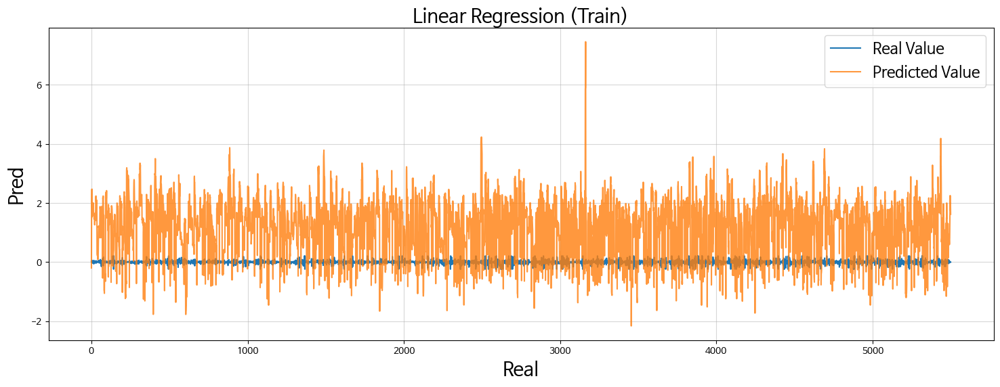

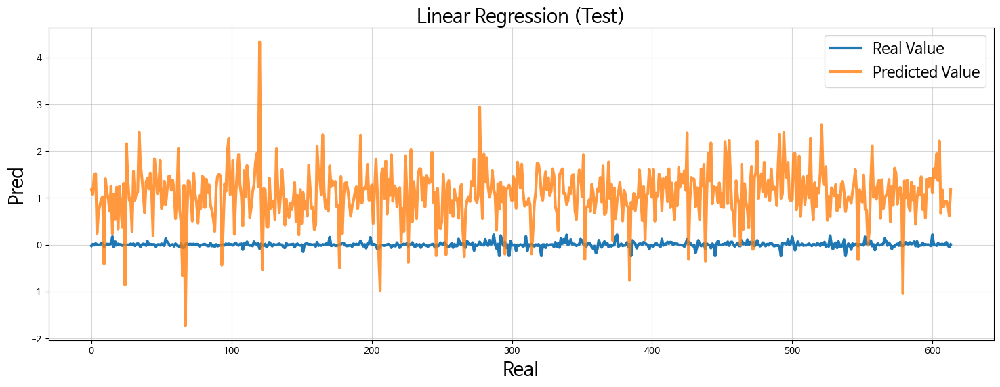

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,Train set,1.6381,2.6834,1.4791,1.4791,1.5281,1.5281,-741.3038
1,Linear Regression,Validation(CV),2.8624,8.1932,2.7089,2.7089,2.7972,2.7972,"-2,217.6348"
2,Linear Regression,Test set,1.2128,1.4709,1.1152,1.1152,1.0983,1.0983,-510.9162
3,Linear Regression,Entire population,1.6005,2.5617,1.4425,1.4425,1.4726,1.4726,-722.3320


   [Save] Linear Regression Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_Linear Regression_20260928_011006.pkl
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_Linear Regression_20260928_011006.json

   Running Machine Learning Algorithm: Random Forest (regression)
Learning...:  2026-09-28 01:10:06.133335


  0%|          | 0/50 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'use_max_depth': False, 'n_estimators': 200, 'max_features': 'log2', 'min_samples_split': 4, 'min_samples_leaf': 45, 'bootstrap': False, 'scaler_type': 'Normalizer'}
  ▶ [Trial 1] Params: {'use_max_depth': True, 'n_estimators': 200, 'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 8, 'min_samples_leaf': 18, 'bootstrap': False, 'scaler_type': 'Normalizer'}
  ▶ [Trial 2] Params: {'use_max_depth': True, 'n_estimators': 100, 'max_depth': 4, 'max_features': 'log2', 'min_samples_split': 10, 'min_samples_leaf': 29, 'bootstrap': True, 'scaler_type': 'None'}
  ▶ [Trial 3] Params: {'use_max_depth': False, 'n_estimators': 200, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 41, 'bootstrap': True, 'scaler_type': 'StandardScaler'}
  ▶ [Trial 4] Params: {'use_max_depth': False, 'n_estimators': 200, 'max_features': 'log2', 'min_samples_split': 10, 'min_samples_leaf': 28, 'bootstrap': True, 'scaler_type': 'RobustScaler'}
  ▶ [Trial 5] Params: {'us

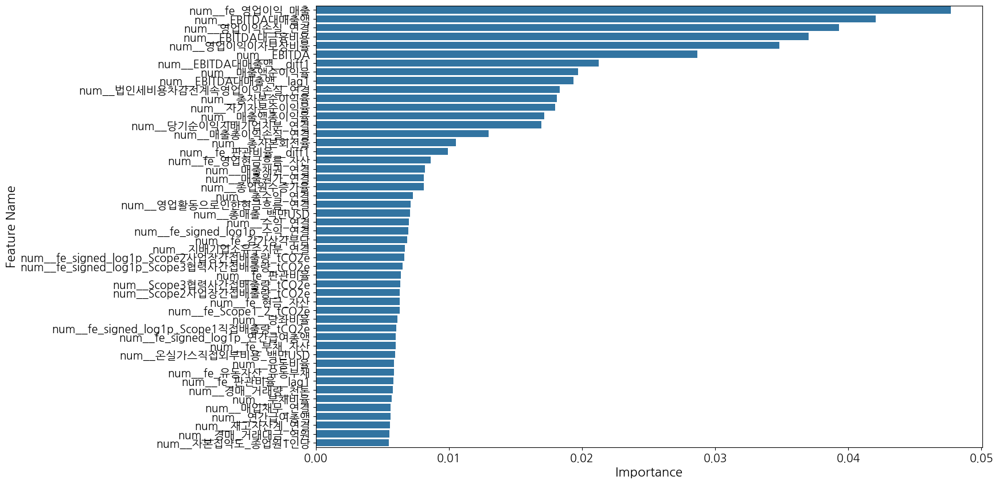

Performance Evaluations...:  2026-09-28 01:16:07.971148
Performance: 


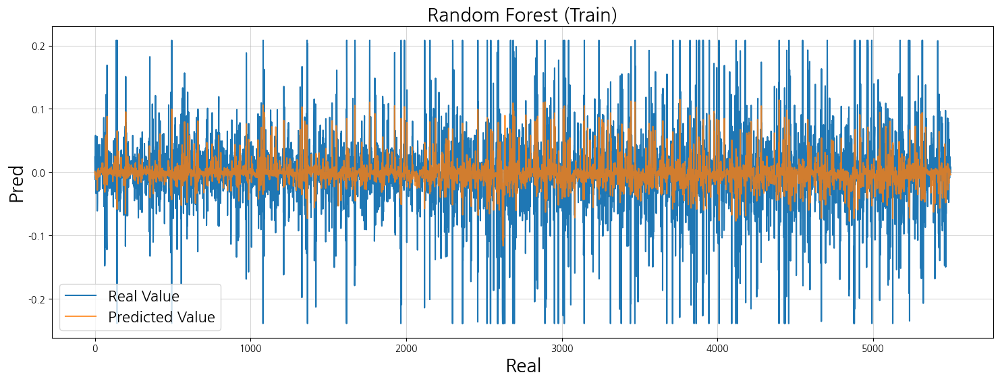

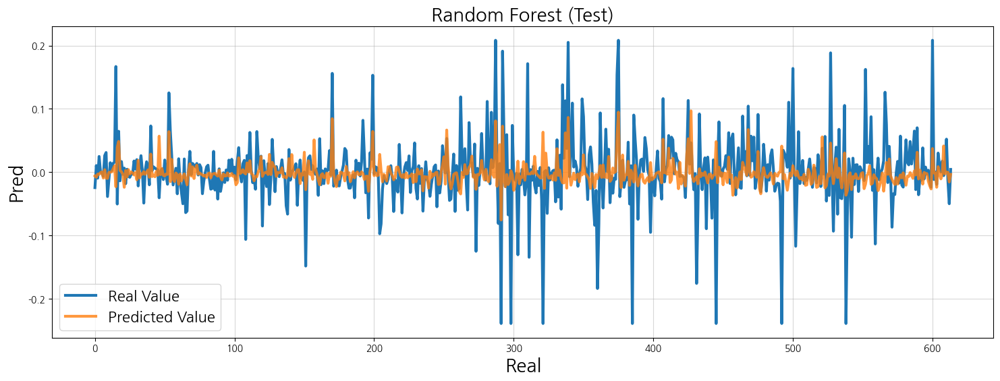

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Random Forest,Train set,0.0467,0.0022,0.0302,0.0302,0.0179,0.0179,0.3961
1,Random Forest,Validation(CV),0.0569,0.0032,0.0353,0.0353,0.0190,0.0190,0.1220
2,Random Forest,Test set,0.0503,0.0025,0.0310,0.0310,0.0175,0.0175,0.1178
3,Random Forest,Entire population,0.0471,0.0022,0.0303,0.0303,0.0179,0.0179,0.3736


   [Save] Random Forest Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_Random Forest_20260928_011615.pkl
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_Random Forest_20260928_011615.json

   Running Machine Learning Algorithm: XGBoost (regression)
Learning...:  2026-09-28 01:16:15.135036


  0%|          | 0/50 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.10187957678704157, 'subsample': 0.6493405088972314, 'colsample_bytree': 0.5690779203430246, 'reg_alpha': 0.0012672392455710703, 'reg_lambda': 0.5949764576910263, 'scaler_type': 'None'}
  ▶ [Trial 1] Params: {'n_estimators': 100, 'max_depth': 12, 'learning_rate': 0.031776351779548344, 'subsample': 0.5910819144835299, 'colsample_bytree': 0.5144193911646886, 'reg_alpha': 0.03828336937659616, 'reg_lambda': 5.189204554739609, 'scaler_type': 'MinMaxScaler'}
  ▶ [Trial 2] Params: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.13734450679952354, 'subsample': 0.6286080700931223, 'colsample_bytree': 0.77715204839182, 'reg_alpha': 3.9842305239877103, 'reg_lambda': 0.4768797260456274, 'scaler_type': 'RobustScaler'}
  ▶ [Trial 3] Params: {'n_estimators': 100, 'max_depth': 11, 'learning_rate': 0.05059309733212994, 'subsample': 0.6992376449077033, 'colsample_bytree': 0.565877686796574, 'reg_alpha': 6.026472713839

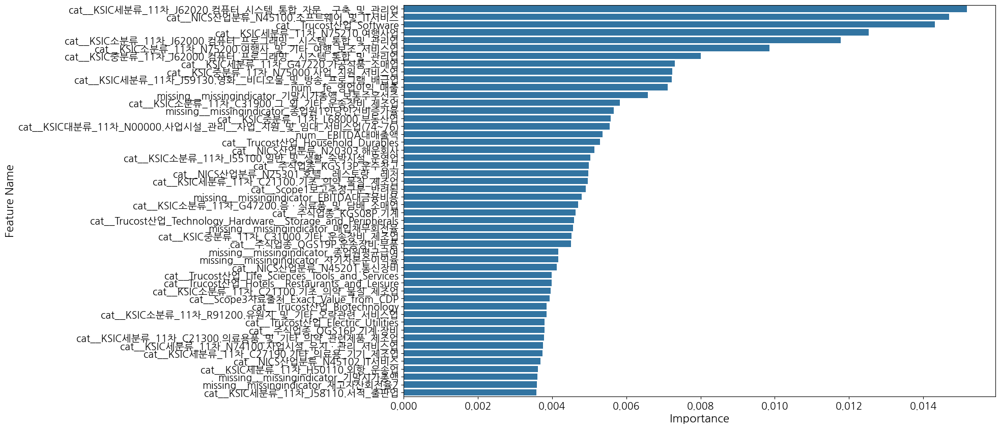

Performance Evaluations...:  2026-09-28 01:18:06.421450
Performance: 


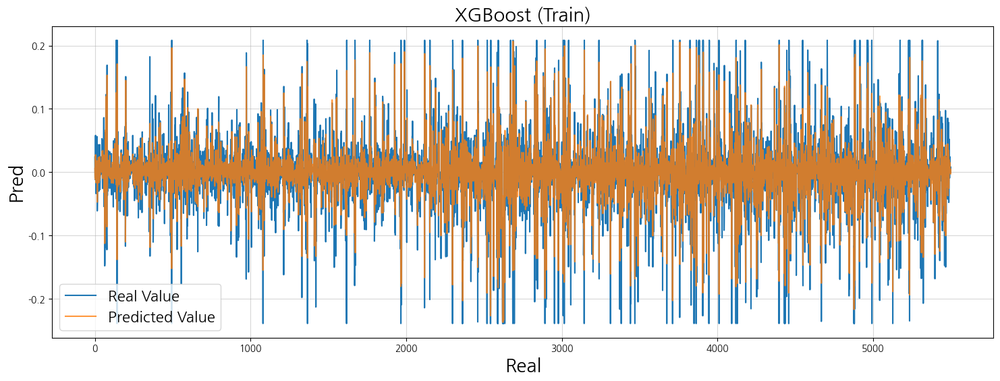

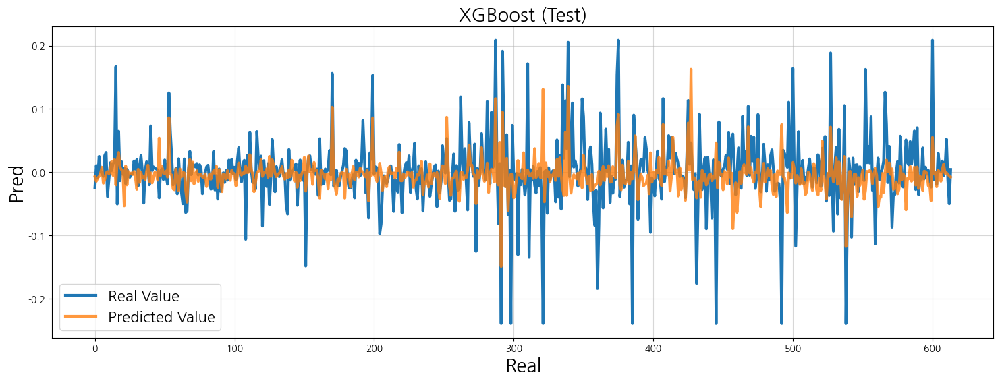

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,XGBoost,Train set,0.0209,0.0004,0.0146,0.0146,0.0100,0.0100,0.8793
1,XGBoost,Validation(CV),0.0555,0.0031,0.0352,0.0352,0.0196,0.0196,0.1666
2,XGBoost,Test set,0.0504,0.0025,0.0313,0.0313,0.0195,0.0195,0.1161
3,XGBoost,Entire population,0.0255,0.0006,0.0162,0.0162,0.0105,0.0105,0.8171


   [Save] XGBoost Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_XGBoost_20260928_011808.pkl
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_XGBoost_20260928_011808.json

   Running Machine Learning Algorithm: LightGBM (regression)
Learning...:  2026-09-28 01:18:08.706501


  0%|          | 0/50 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'n_estimators': 400, 'learning_rate': 0.023628886069974167, 'num_leaves': 42, 'max_depth': 7, 'subsample': 0.799715012413707, 'colsample_bytree': 0.752555215890421, 'reg_alpha': 0.0010272973355565699, 'reg_lambda': 1.4923718133543489, 'scaler_type': 'RobustScaler'}
  ▶ [Trial 1] Params: {'n_estimators': 500, 'learning_rate': 0.027143716636210045, 'num_leaves': 95, 'max_depth': 7, 'subsample': 0.7859656549529317, 'colsample_bytree': 0.6309157688007719, 'reg_alpha': 0.005882467402856652, 'reg_lambda': 6.372023371217314, 'scaler_type': 'Normalizer'}
  ▶ [Trial 2] Params: {'n_estimators': 300, 'learning_rate': 0.041297630249477676, 'num_leaves': 72, 'max_depth': 4, 'subsample': 0.7314735436485442, 'colsample_bytree': 0.5453230393338729, 'reg_alpha': 0.06775550157566793, 'reg_lambda': 0.05900915989494858, 'scaler_type': 'None'}
  ▶ [Trial 3] Params: {'n_estimators': 500, 'learning_rate': 0.0208838435879401, 'num_leaves': 72, 'max_depth': 11, 'subsample': 0.71030196100

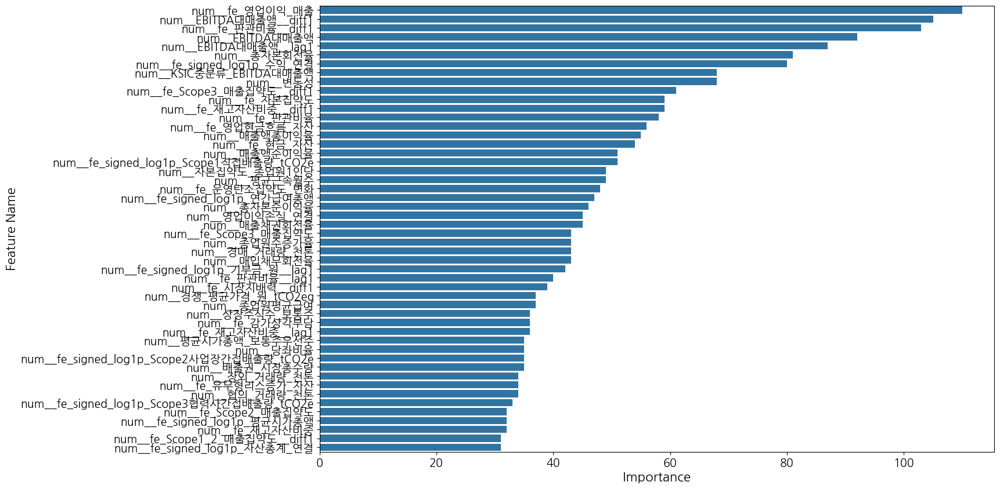

Performance Evaluations...:  2026-09-28 01:19:26.349187
Performance: 


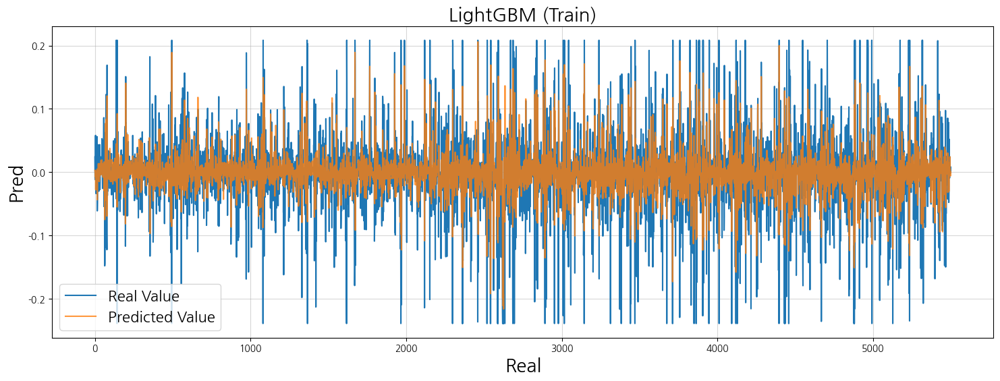

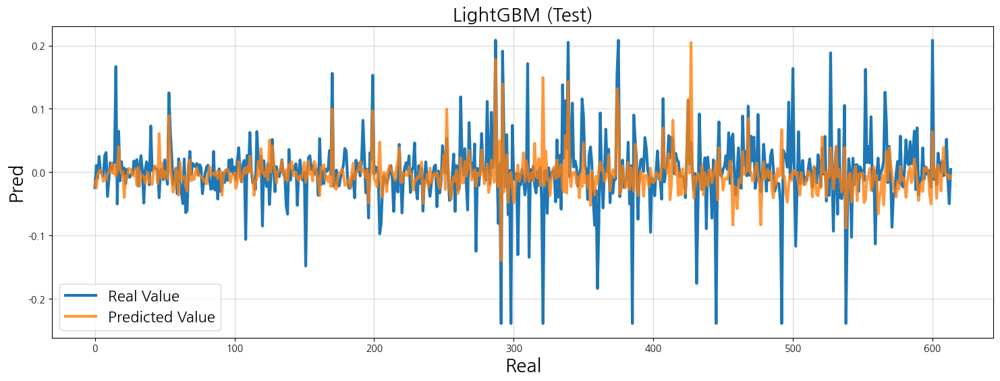

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,LightGBM,Train set,0.0373,0.0014,0.0252,0.0252,0.0165,0.0165,0.6157
1,LightGBM,Validation(CV),0.0553,0.0031,0.0345,0.0345,0.0194,0.0194,0.1730
2,LightGBM,Test set,0.0510,0.0026,0.0320,0.0320,0.0199,0.0199,0.0939
3,LightGBM,Entire population,0.0389,0.0015,0.0259,0.0259,0.0169,0.0169,0.5733


   [Save] LightGBM Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_LightGBM_20260928_011928.pkl
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_LightGBM_20260928_011928.json

   Running Machine Learning Algorithm: CatBoost (regression)
Learning...:  2026-09-28 01:19:28.059163


  0%|          | 0/50 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'n_estimators': 300, 'depth': 6, 'learning_rate': 0.02266205033359731, 'l2_leaf_reg': 3.763204436958164, 'subsample': 0.6282654775744858, 'scaler_type': 'Normalizer'}
  ▶ [Trial 1] Params: {'n_estimators': 200, 'depth': 4, 'learning_rate': 0.13271989266776427, 'l2_leaf_reg': 6.040734058316965, 'subsample': 0.6490690278125878, 'scaler_type': 'None'}
  ▶ [Trial 2] Params: {'n_estimators': 400, 'depth': 6, 'learning_rate': 0.010306337103521045, 'l2_leaf_reg': 5.931027438821575, 'subsample': 0.5868654756843825, 'scaler_type': 'Normalizer'}
  ▶ [Trial 3] Params: {'n_estimators': 300, 'depth': 8, 'learning_rate': 0.03752038777711869, 'l2_leaf_reg': 8.411973379227865, 'subsample': 0.6849728131974839, 'scaler_type': 'Normalizer'}
  ▶ [Trial 4] Params: {'n_estimators': 100, 'depth': 8, 'learning_rate': 0.18481924625239032, 'l2_leaf_reg': 5.629465964500939, 'subsample': 0.7985743779130539, 'scaler_type': 'Normalizer'}
  ▶ [Trial 5] Params: {'n_estimators': 200, 'depth': 8,

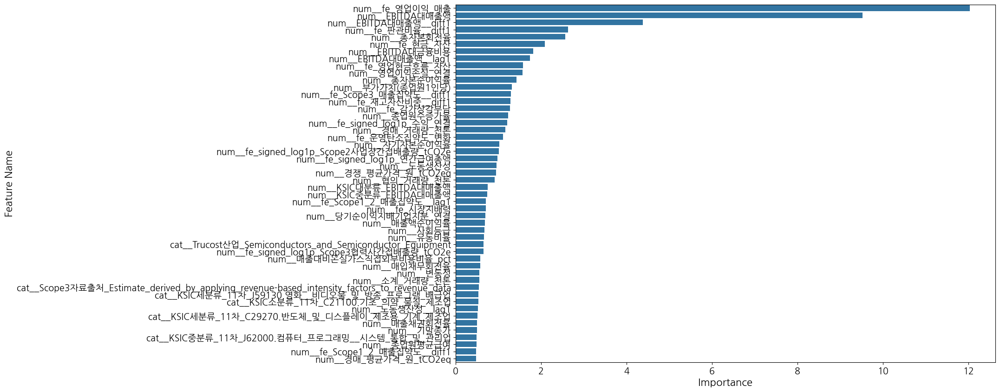

Performance Evaluations...:  2026-09-28 01:20:50.292418
Performance: 


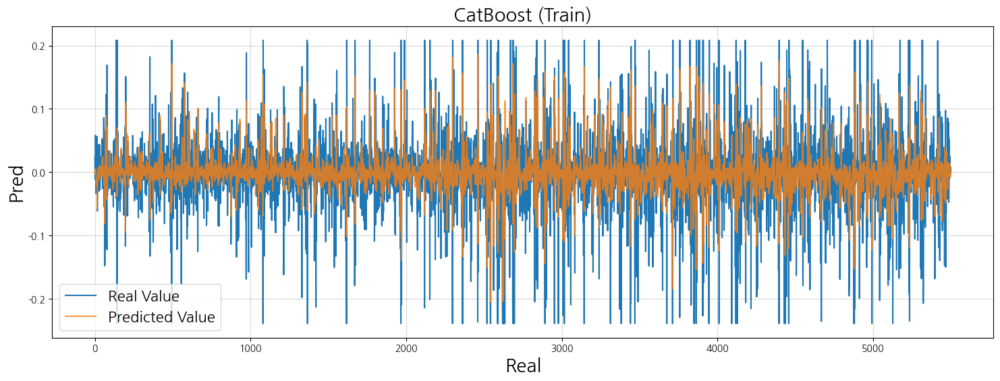

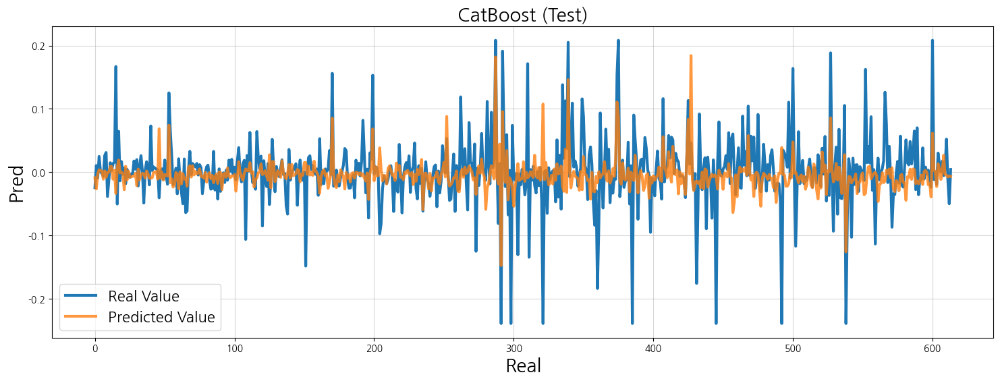

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,CatBoost,Train set,0.0420,0.0018,0.0291,0.0291,0.0195,0.0195,0.5111
1,CatBoost,Validation(CV),0.0551,0.0030,0.0350,0.0350,0.0194,0.0194,0.1771
2,CatBoost,Test set,0.0502,0.0025,0.0316,0.0316,0.0179,0.0179,0.1227
3,CatBoost,Entire population,0.0429,0.0018,0.0293,0.0293,0.0194,0.0194,0.4796


   [Save] CatBoost Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_CatBoost_20260928_012051.pkl
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_CatBoost_20260928_012051.json

   Modeling Completed. Summary of Performance (regression)


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,Train set,1.6381,2.6834,1.4791,1.4791,1.5281,1.5281,-741.3038
4,Random Forest,Train set,0.0467,0.0022,0.0302,0.0302,0.0179,0.0179,0.3961
8,XGBoost,Train set,0.0209,0.0004,0.0146,0.0146,0.0100,0.0100,0.8793
12,LightGBM,Train set,0.0373,0.0014,0.0252,0.0252,0.0165,0.0165,0.6157
16,CatBoost,Train set,0.0420,0.0018,0.0291,0.0291,0.0195,0.0195,0.5111


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
1,Linear Regression,Validation(CV),2.8624,8.1932,2.7089,2.7089,2.7972,2.7972,-2217.6348
5,Random Forest,Validation(CV),0.0569,0.0032,0.0353,0.0353,0.0190,0.0190,0.1220
9,XGBoost,Validation(CV),0.0555,0.0031,0.0352,0.0352,0.0196,0.0196,0.1666
13,LightGBM,Validation(CV),0.0553,0.0031,0.0345,0.0345,0.0194,0.0194,0.1730
17,CatBoost,Validation(CV),0.0551,0.0030,0.0350,0.0350,0.0194,0.0194,0.1771


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
2,Linear Regression,Test set,1.2128,1.4709,1.1152,1.1152,1.0983,1.0983,-510.9162
6,Random Forest,Test set,0.0503,0.0025,0.0310,0.0310,0.0175,0.0175,0.1178
10,XGBoost,Test set,0.0504,0.0025,0.0313,0.0313,0.0195,0.0195,0.1161
14,LightGBM,Test set,0.0510,0.0026,0.0320,0.0320,0.0199,0.0199,0.0939
18,CatBoost,Test set,0.0502,0.0025,0.0316,0.0316,0.0179,0.0179,0.1227


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
3,Linear Regression,Entire population,1.6005,2.5617,1.4425,1.4425,1.4726,1.4726,-722.3320
7,Random Forest,Entire population,0.0471,0.0022,0.0303,0.0303,0.0179,0.0179,0.3736
11,XGBoost,Entire population,0.0255,0.0006,0.0162,0.0162,0.0105,0.0105,0.8171
15,LightGBM,Entire population,0.0389,0.0015,0.0259,0.0259,0.0169,0.0169,0.5733
19,CatBoost,Entire population,0.0429,0.0018,0.0293,0.0293,0.0194,0.0194,0.4796


Saved total performance to: /workspace/DataScience/DIVE/Project/CO2XAI/Result/Performance_ML(Trial50).csv
Saved total parameters to: /workspace/DataScience/DIVE/Project/CO2XAI/Result/Hyperparams_ML(Trial50).csv
Saved total results object to: /workspace/DataScience/DIVE/Project/CO2XAI/Model/Best_Result_ML(Trial50).pkl


In [5]:
# ML Modeling
results_ML, scores_ML = modeling_ML(
    algos=ALGO_NAMES_ML,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    task=TASK,
    X_colname=X_colname,
    params=None, # 특정 알고리즘
    tune_trials=TUNE_TRIALS_ML, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC_ML,
    X_top_display=X_TOP_DISPLAY, 
    label_list=LABEL_LIST,
    random_state=RANDOM_STATE,
)


## Deep Learning

▶ Manually Specified Task Type: [ regression ]

[Info] Applying Out-Of-Time (OOT) Validation using cv_splits indices.

   Running Deep Learning Algorithm: MLP (regression)
[Info] Starting Hyperparameter Optimization (Trials: 10)...


  0%|          | 0/10 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'scaler_type': 'None', 'n_layers': 2, 'l2_regularization': 1.7197525158904508e-06, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.4684289078914926, 'batch_size': 256, 'optimizer': 'sgd', 'learning_rate': 0.0016155672184590456, 'first_layer_nodes': 64, 'shape': 'funnel'}


Training Progress: 100%|██████████| 100/100 [00:18<00:00,  5.52it/s]


  ▶ [Trial 1] Params: {'scaler_type': 'None', 'n_layers': 2, 'l2_regularization': 0.000450869937155075, 'batch_normalization': False, 'hidden_activation': 'swish', 'dropout': 0.4566657421480417, 'batch_size': 256, 'optimizer': 'sgd', 'learning_rate': 0.00034676285067965733, 'first_layer_nodes': 256, 'shape': 'constant'}


Training Progress: 100%|██████████| 100/100 [00:16<00:00,  6.23it/s]


  ▶ [Trial 2] Params: {'scaler_type': 'RobustScaler', 'n_layers': 3, 'l2_regularization': 7.244702533113695e-05, 'batch_normalization': False, 'hidden_activation': 'relu', 'dropout': 0.4661975325638029, 'batch_size': 128, 'optimizer': 'rmsprop', 'learning_rate': 0.0002520492521895141, 'first_layer_nodes': 128, 'shape': 'constant'}


Training Progress:  50%|█████     | 50/100 [00:11<00:11,  4.22it/s]


  ▶ [Trial 3] Params: {'scaler_type': 'StandardScaler', 'n_layers': 2, 'l2_regularization': 1.991957483079452e-06, 'batch_normalization': True, 'hidden_activation': 'selu', 'dropout': 0.2875008607871676, 'batch_size': 256, 'optimizer': 'sgd', 'learning_rate': 0.000690367472516249, 'first_layer_nodes': 192, 'shape': 'funnel'}


Training Progress: 100%|██████████| 100/100 [00:17<00:00,  5.65it/s]


  ▶ [Trial 4] Params: {'scaler_type': 'MinMaxScaler', 'n_layers': 2, 'l2_regularization': 0.00013830346264480863, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.37746129384738697, 'batch_size': 512, 'optimizer': 'rmsprop', 'learning_rate': 0.0001500446890927031, 'first_layer_nodes': 192, 'shape': 'constant'}


Training Progress:  13%|█▎        | 13/100 [00:01<00:10,  8.47it/s]


  ▶ [Trial 5] Params: {'scaler_type': 'RobustScaler', 'n_layers': 2, 'l2_regularization': 5.631044038499659e-06, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.20927176666321834, 'batch_size': 512, 'optimizer': 'rmsprop', 'learning_rate': 0.00018777511857126917, 'first_layer_nodes': 256, 'shape': 'funnel'}


Training Progress: 100%|██████████| 100/100 [00:13<00:00,  7.36it/s]


  ▶ [Trial 6] Params: {'scaler_type': 'RobustScaler', 'n_layers': 3, 'l2_regularization': 0.0001544567125584333, 'batch_normalization': False, 'hidden_activation': 'swish', 'dropout': 0.45298680281960746, 'batch_size': 1024, 'optimizer': 'sgd', 'learning_rate': 0.0001489534333365858, 'first_layer_nodes': 64, 'shape': 'constant'}


Training Progress: 100%|██████████| 100/100 [00:10<00:00,  9.10it/s]


  ▶ [Trial 7] Params: {'scaler_type': 'RobustScaler', 'n_layers': 2, 'l2_regularization': 0.0001429674976772632, 'batch_normalization': True, 'hidden_activation': 'swish', 'dropout': 0.1573294916063559, 'batch_size': 1024, 'optimizer': 'sgd', 'learning_rate': 0.0001336122892443642, 'first_layer_nodes': 192, 'shape': 'funnel'}


Training Progress: 100%|██████████| 100/100 [00:11<00:00,  8.97it/s]


  ▶ [Trial 8] Params: {'scaler_type': 'RobustScaler', 'n_layers': 2, 'l2_regularization': 3.3719521568768955e-05, 'batch_normalization': True, 'hidden_activation': 'swish', 'dropout': 0.49288564492944825, 'batch_size': 1024, 'optimizer': 'adamw', 'learning_rate': 0.0001682877249768416, 'first_layer_nodes': 128, 'shape': 'constant'}


Training Progress: 100%|██████████| 100/100 [00:11<00:00,  8.80it/s]


  ▶ [Trial 9] Params: {'scaler_type': 'MinMaxScaler', 'n_layers': 1, 'l2_regularization': 7.061852004787512e-06, 'batch_normalization': True, 'hidden_activation': 'relu', 'dropout': 0.19707793252572253, 'batch_size': 1024, 'optimizer': 'adam', 'learning_rate': 0.001692091632742528, 'first_layer_nodes': 256, 'shape': 'funnel'}


Training Progress:  11%|█         | 11/100 [00:01<00:08,  9.90it/s]


[MLP] Best Metric Trial:  2
[MLP] Best Tuning Parameters:  {'scaler_type': 'RobustScaler', 'n_layers': 3, 'l2_regularization': 7.244702533113695e-05, 'batch_normalization': False, 'hidden_activation': 'relu', 'dropout': 0.4661975325638029, 'batch_size': 128, 'optimizer': 'rmsprop', 'learning_rate': 0.0002520492521895141, 'first_layer_nodes': 128, 'shape': 'constant'}
[MLP] Best Metric Score:  0.06101835793507993



Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

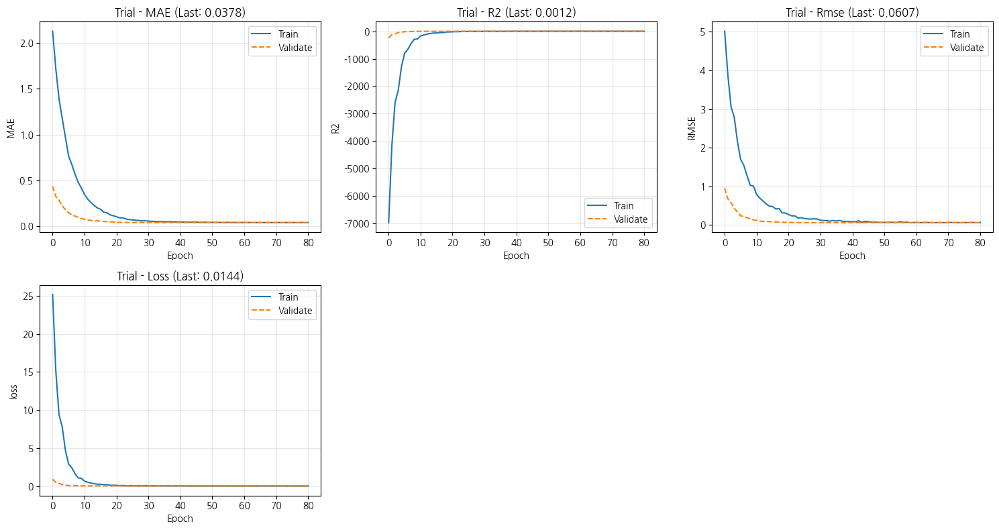

Training Progress:  81%|████████  | 81/100 [00:35<00:08,  2.26it/s]


   [Save] MLP Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_MLP_20260924_000737.keras
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_MLP_20260924_000737.json
Performance: 


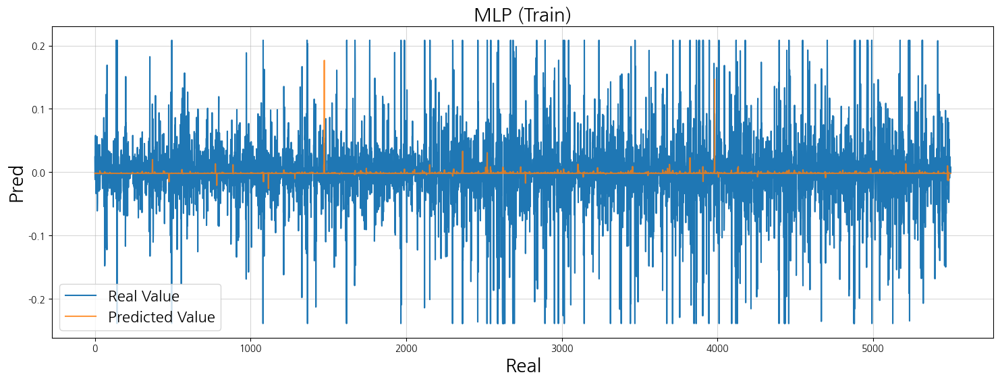

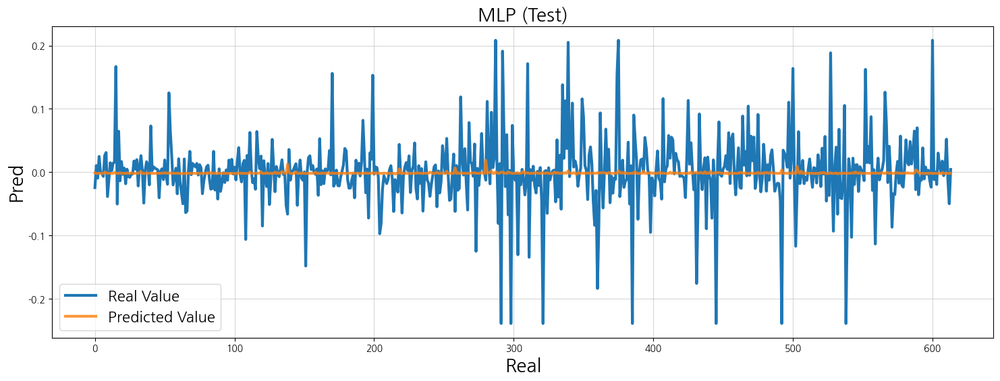

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,MLP,Train set,0.0601,0.0036,0.0384,0.0384,0.0221,0.0221,-0.0005
1,MLP,Validation(CV),0.0607,0.0037,0.0378,0.0378,0.0197,0.0197,0.0022
2,MLP,Test set,0.0537,0.0029,0.0329,0.0329,0.0180,0.0180,-0.0038
3,MLP,Entire population,0.0595,0.0035,0.0379,0.0379,0.0216,0.0216,-0.0005



   Running Deep Learning Algorithm: CNN (regression)
[Info] Starting Hyperparameter Optimization (Trials: 10)...


  0%|          | 0/10 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'scaler_type': 'None', 'n_layers': 1, 'l2_regularization': 0.0005143504758914647, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.09060714443869633, 'batch_size': 128, 'optimizer': 'rmsprop', 'learning_rate': 0.0014657850523445456, 'base_filters': 64, 'kernel_size': 5}


Training Progress:  33%|███▎      | 33/100 [00:07<00:15,  4.21it/s]


  ▶ [Trial 1] Params: {'scaler_type': 'None', 'n_layers': 2, 'l2_regularization': 0.0003812836068846586, 'batch_normalization': False, 'hidden_activation': 'swish', 'dropout': 0.49414353959032525, 'batch_size': 1024, 'optimizer': 'rmsprop', 'learning_rate': 0.00010320504466101267, 'base_filters': 16, 'kernel_size': 7}


Training Progress:  66%|██████▌   | 66/100 [00:07<00:03,  8.69it/s]


  ▶ [Trial 2] Params: {'scaler_type': 'MinMaxScaler', 'n_layers': 2, 'l2_regularization': 3.9923987588216627e-05, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.09049917277883135, 'batch_size': 256, 'optimizer': 'rmsprop', 'learning_rate': 0.0006547666278966123, 'base_filters': 16, 'kernel_size': 3}


Training Progress:  15%|█▌        | 15/100 [00:02<00:16,  5.02it/s]


  ▶ [Trial 3] Params: {'scaler_type': 'None', 'n_layers': 3, 'l2_regularization': 0.0005598333175953691, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.11941787045459606, 'batch_size': 1024, 'optimizer': 'rmsprop', 'learning_rate': 0.00015052505094800025, 'base_filters': 64, 'kernel_size': 7}


Training Progress:  11%|█         | 11/100 [00:02<00:23,  3.77it/s]


  ▶ [Trial 4] Params: {'scaler_type': 'MinMaxScaler', 'n_layers': 2, 'l2_regularization': 1.703341191712291e-06, 'batch_normalization': False, 'hidden_activation': 'gelu', 'dropout': 0.11191313561966215, 'batch_size': 1024, 'optimizer': 'adam', 'learning_rate': 0.0009026010502242039, 'base_filters': 64, 'kernel_size': 7}


Training Progress: 100%|██████████| 100/100 [00:15<00:00,  6.55it/s]


  ▶ [Trial 5] Params: {'scaler_type': 'StandardScaler', 'n_layers': 1, 'l2_regularization': 1.059674380669874e-05, 'batch_normalization': True, 'hidden_activation': 'relu', 'dropout': 0.3116035095049909, 'batch_size': 256, 'optimizer': 'sgd', 'learning_rate': 0.0002881742899837001, 'base_filters': 16, 'kernel_size': 3}


Training Progress:  11%|█         | 11/100 [00:01<00:14,  6.15it/s]


  ▶ [Trial 6] Params: {'scaler_type': 'RobustScaler', 'n_layers': 1, 'l2_regularization': 0.0005922476487072643, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.12366458309222278, 'batch_size': 128, 'optimizer': 'rmsprop', 'learning_rate': 0.00019543632356523616, 'base_filters': 64, 'kernel_size': 5}


Training Progress:  39%|███▉      | 39/100 [00:09<00:14,  4.25it/s]


  ▶ [Trial 7] Params: {'scaler_type': 'MinMaxScaler', 'n_layers': 3, 'l2_regularization': 1.2209067418684447e-05, 'batch_normalization': True, 'hidden_activation': 'relu', 'dropout': 0.2142630898602017, 'batch_size': 512, 'optimizer': 'adam', 'learning_rate': 0.000441773852394, 'base_filters': 64, 'kernel_size': 7}


Training Progress:  21%|██        | 21/100 [00:05<00:22,  3.55it/s]


  ▶ [Trial 8] Params: {'scaler_type': 'StandardScaler', 'n_layers': 2, 'l2_regularization': 4.988068901848803e-05, 'batch_normalization': True, 'hidden_activation': 'selu', 'dropout': 0.0760872074557839, 'batch_size': 256, 'optimizer': 'adamw', 'learning_rate': 0.000714302398929025, 'base_filters': 64, 'kernel_size': 3}


Training Progress:  31%|███       | 31/100 [00:07<00:16,  4.30it/s]


  ▶ [Trial 9] Params: {'scaler_type': 'StandardScaler', 'n_layers': 1, 'l2_regularization': 4.180765622752324e-06, 'batch_normalization': True, 'hidden_activation': 'swish', 'dropout': 0.07296764511934645, 'batch_size': 256, 'optimizer': 'adam', 'learning_rate': 0.0018936998649741394, 'base_filters': 16, 'kernel_size': 7}


Training Progress:  72%|███████▏  | 72/100 [00:12<00:04,  5.81it/s]


[CNN] Best Metric Trial:  4
[CNN] Best Tuning Parameters:  {'scaler_type': 'MinMaxScaler', 'n_layers': 2, 'l2_regularization': 1.703341191712291e-06, 'batch_normalization': False, 'hidden_activation': 'gelu', 'dropout': 0.11191313561966215, 'batch_size': 1024, 'optimizer': 'adam', 'learning_rate': 0.0009026010502242039, 'base_filters': 64, 'kernel_size': 7}
[CNN] Best Metric Score:  0.06052814979357484



Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

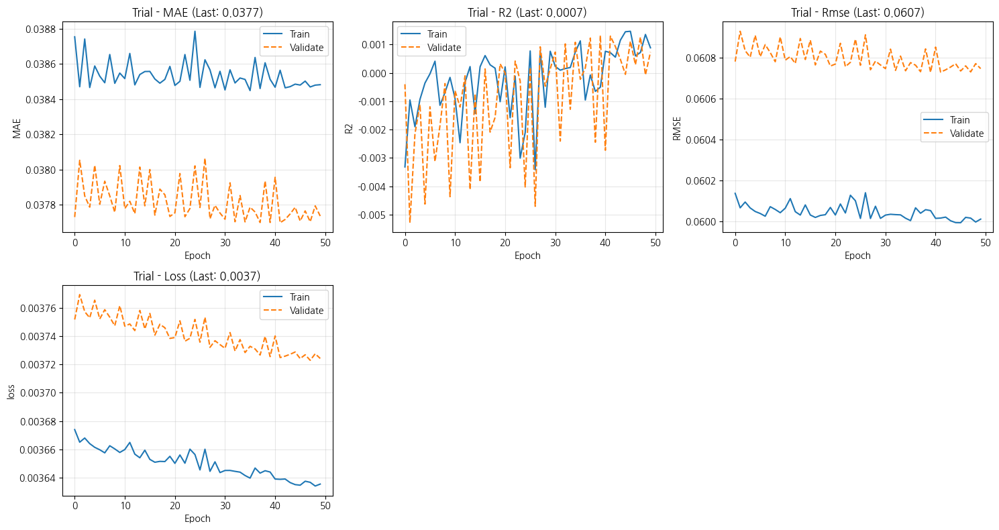

Training Progress:  50%|█████     | 50/100 [00:16<00:16,  3.12it/s]


   [Save] CNN Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_CNN_20260924_000931.keras
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_CNN_20260924_000931.json
Performance: 


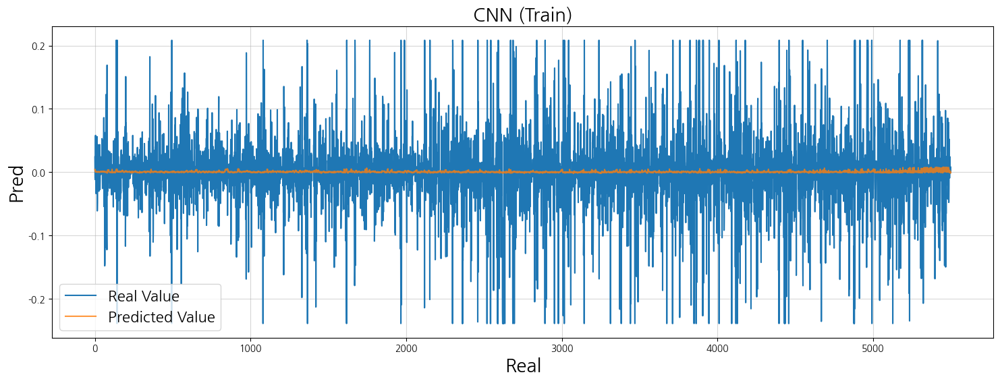

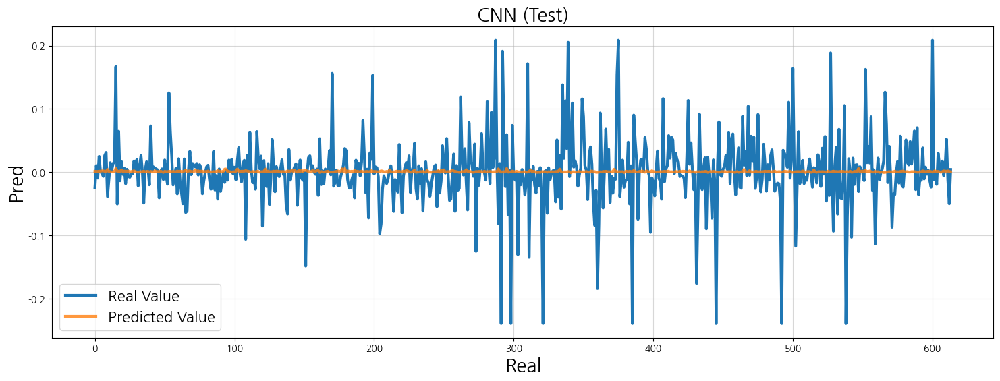

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,CNN,Train set,0.0601,0.0036,0.0383,0.0383,0.0222,0.0222,0.0001
1,CNN,Validation(CV),0.0607,0.0037,0.0377,0.0377,0.0204,0.0204,0.0013
2,CNN,Test set,0.0536,0.0029,0.0327,0.0327,0.0179,0.0179,-0.0001
3,CNN,Entire population,0.0595,0.0035,0.0378,0.0378,0.0216,0.0216,0.0003



   Running Deep Learning Algorithm: TabNet (regression)
[Info] Starting Hyperparameter Optimization (Trials: 10)...


  0%|          | 0/10 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'scaler_type': 'StandardScaler', 'n_layers': 2, 'l2_regularization': 8.122233412307239e-05, 'batch_normalization': False, 'hidden_activation': 'gelu', 'dropout': 0.41489782652290935, 'batch_size': 1024, 'optimizer': 'adam', 'learning_rate': 0.00027861617468697054, 'batch_size_tabnet': 256, 'n_d': 32, 'n_steps': 4, 'gamma': 1.2343887866543843, 'n_independent': 2, 'n_shared': 2, 'mask_type': 'entmax'}


Training Progress: 100%|██████████| 100/100 [00:35<00:00,  2.82it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 60 and best_val_mse = 0.10779


  ▶ [Trial 1] Params: {'scaler_type': 'RobustScaler', 'n_layers': 1, 'l2_regularization': 4.223996892713579e-06, 'batch_normalization': False, 'hidden_activation': 'gelu', 'dropout': 0.4130847504066525, 'batch_size': 128, 'optimizer': 'adam', 'learning_rate': 0.0037778975778069612, 'batch_size_tabnet': 512, 'n_d': 32, 'n_steps': 4, 'gamma': 1.4551603356604512, 'n_independent': 2, 'n_shared': 2, 'mask_type': 'entmax'}


Training Progress: 100%|██████████| 100/100 [00:26<00:00,  3.79it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 37 and best_val_mse = 0.00366


  ▶ [Trial 2] Params: {'scaler_type': 'RobustScaler', 'n_layers': 3, 'l2_regularization': 1.3399163915601435e-06, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.45490964563714104, 'batch_size': 128, 'optimizer': 'sgd', 'learning_rate': 0.00023397891348997488, 'batch_size_tabnet': 256, 'n_d': 16, 'n_steps': 3, 'gamma': 1.1763598602859324, 'n_independent': 1, 'n_shared': 2, 'mask_type': 'sparsemax'}


Training Progress: 100%|██████████| 100/100 [00:28<00:00,  3.54it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 1 and best_val_mse = 0.0131


  ▶ [Trial 3] Params: {'scaler_type': 'MinMaxScaler', 'n_layers': 3, 'l2_regularization': 2.4434666212073566e-05, 'batch_normalization': True, 'hidden_activation': 'selu', 'dropout': 0.392691400588776, 'batch_size': 256, 'optimizer': 'sgd', 'learning_rate': 0.0026322285028780707, 'batch_size_tabnet': 512, 'n_d': 8, 'n_steps': 3, 'gamma': 1.327932838064849, 'n_independent': 1, 'n_shared': 2, 'mask_type': 'sparsemax'}


Training Progress: 100%|██████████| 100/100 [00:21<00:00,  4.65it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 56 and best_val_mse = 0.00369


  ▶ [Trial 4] Params: {'scaler_type': 'None', 'n_layers': 3, 'l2_regularization': 2.4209608548058996e-06, 'batch_normalization': True, 'hidden_activation': 'gelu', 'dropout': 0.49697426425326824, 'batch_size': 128, 'optimizer': 'adam', 'learning_rate': 0.002134708064882193, 'batch_size_tabnet': 128, 'n_d': 32, 'n_steps': 4, 'gamma': 1.335094191605998, 'n_independent': 1, 'n_shared': 1, 'mask_type': 'entmax'}


Training Progress: 100%|██████████| 100/100 [00:45<00:00,  2.20it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 15 and best_val_mse = 0.00365


  ▶ [Trial 5] Params: {'scaler_type': 'RobustScaler', 'n_layers': 3, 'l2_regularization': 0.00010181997485763091, 'batch_normalization': False, 'hidden_activation': 'swish', 'dropout': 0.06399555765511167, 'batch_size': 256, 'optimizer': 'adam', 'learning_rate': 0.0005422786542951971, 'batch_size_tabnet': 256, 'n_d': 16, 'n_steps': 4, 'gamma': 1.4618074023952046, 'n_independent': 2, 'n_shared': 1, 'mask_type': 'entmax'}


Training Progress: 100%|██████████| 100/100 [00:32<00:00,  3.11it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 81 and best_val_mse = 0.00369


  ▶ [Trial 6] Params: {'scaler_type': 'RobustScaler', 'n_layers': 2, 'l2_regularization': 0.0003497713946648369, 'batch_normalization': False, 'hidden_activation': 'gelu', 'dropout': 0.11212513990038214, 'batch_size': 256, 'optimizer': 'adamw', 'learning_rate': 0.0027124078708785663, 'batch_size_tabnet': 256, 'n_d': 32, 'n_steps': 4, 'gamma': 1.1749087366286115, 'n_independent': 1, 'n_shared': 2, 'mask_type': 'entmax'}


Training Progress: 100%|██████████| 100/100 [00:32<00:00,  3.11it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 24 and best_val_mse = 0.00369


  ▶ [Trial 7] Params: {'scaler_type': 'StandardScaler', 'n_layers': 2, 'l2_regularization': 6.771455663554525e-06, 'batch_normalization': True, 'hidden_activation': 'swish', 'dropout': 0.07232056128424863, 'batch_size': 1024, 'optimizer': 'sgd', 'learning_rate': 0.0032088961790794138, 'batch_size_tabnet': 128, 'n_d': 8, 'n_steps': 3, 'gamma': 1.2169882767523856, 'n_independent': 2, 'n_shared': 1, 'mask_type': 'entmax'}


Training Progress: 100%|██████████| 100/100 [00:44<00:00,  2.24it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 87 and best_val_mse = 0.00363


  ▶ [Trial 8] Params: {'scaler_type': 'None', 'n_layers': 2, 'l2_regularization': 2.120073194333316e-05, 'batch_normalization': False, 'hidden_activation': 'selu', 'dropout': 0.35914416122777626, 'batch_size': 512, 'optimizer': 'rmsprop', 'learning_rate': 0.0015753161287475877, 'batch_size_tabnet': 512, 'n_d': 16, 'n_steps': 4, 'gamma': 1.2512218951247531, 'n_independent': 2, 'n_shared': 2, 'mask_type': 'sparsemax'}


Training Progress: 100%|██████████| 100/100 [00:26<00:00,  3.81it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 53 and best_val_mse = 0.00369


  ▶ [Trial 9] Params: {'scaler_type': 'MinMaxScaler', 'n_layers': 2, 'l2_regularization': 8.047344283649077e-05, 'batch_normalization': False, 'hidden_activation': 'selu', 'dropout': 0.11603580433192412, 'batch_size': 256, 'optimizer': 'sgd', 'learning_rate': 0.004259896731021931, 'batch_size_tabnet': 256, 'n_d': 32, 'n_steps': 3, 'gamma': 1.116680120896725, 'n_independent': 2, 'n_shared': 1, 'mask_type': 'entmax'}


Training Progress: 100%|██████████| 100/100 [00:28<00:00,  3.53it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 43 and best_val_mse = 0.00361


[TabNet] Best Metric Trial:  9
[TabNet] Best Tuning Parameters:  {'scaler_type': 'MinMaxScaler', 'n_layers': 2, 'l2_regularization': 8.047344283649077e-05, 'batch_normalization': False, 'hidden_activation': 'selu', 'dropout': 0.11603580433192412, 'batch_size': 256, 'optimizer': 'sgd', 'learning_rate': 0.004259896731021931, 'batch_size_tabnet': 256, 'n_d': 32, 'n_steps': 3, 'gamma': 1.116680120896725, 'n_independent': 2, 'n_shared': 1, 'mask_type': 'entmax'}
[TabNet] Best Metric Score:  0.06012192657473395



Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

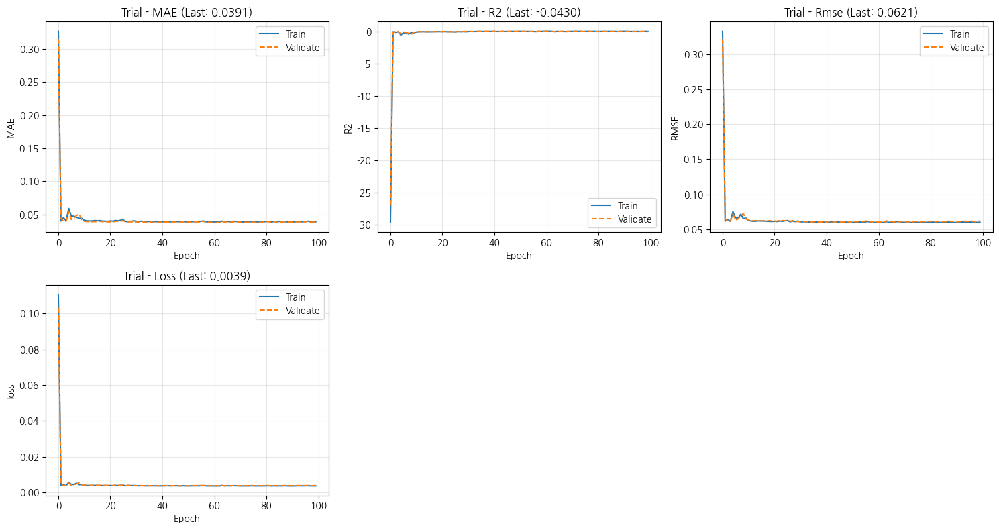

Training Progress: 100%|██████████| 100/100 [00:48<00:00,  2.28it/s]

Stop training because you reached max_epochs = 100 with best_epoch = 43 and best_val_mse = 0.00361


Training Progress: 100%|██████████| 100/100 [00:49<00:00,  2.03it/s]


Successfully saved model at /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_TabNet_20260924_001608.zip
   [Save] TabNet Checkpoint Saved:
     - Model : /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_model_TabNet_20260924_001608.zip
     - Params: /workspace/DataScience/DIVE/Project/CO2XAI/Model/best_params_TabNet_20260924_001608.json
Performance: 


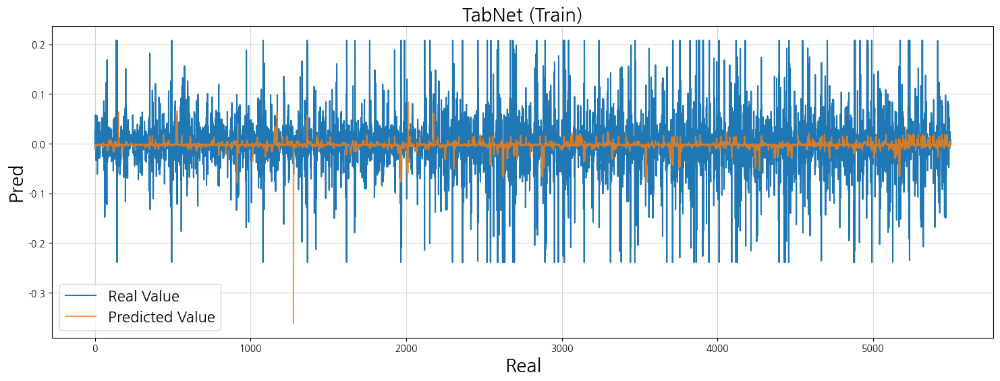

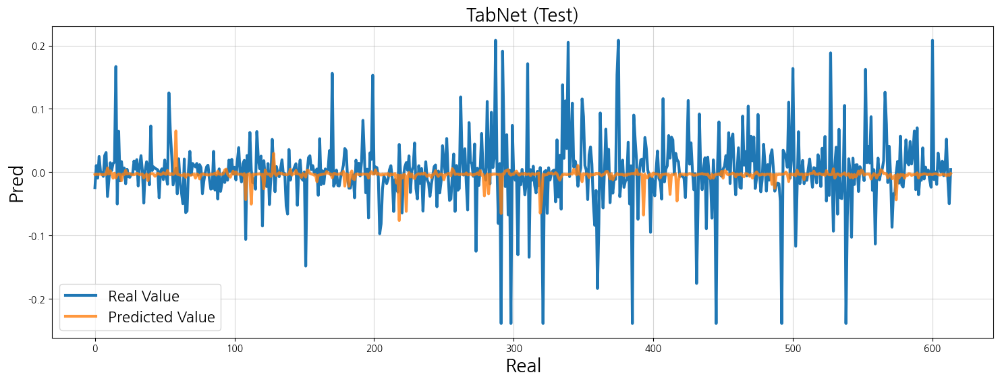

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,TabNet,Train set,0.0601,0.0036,0.0387,0.0387,0.0225,0.0225,0.0024
1,TabNet,Validation(CV),0.0601,0.0036,0.0377,0.0377,0.0202,0.0202,0.0212
2,TabNet,Test set,0.0542,0.0029,0.0338,0.0338,0.0195,0.0195,-0.0221
3,TabNet,Entire population,0.0595,0.0035,0.0382,0.0382,0.0221,0.0221,0.0007



   Modeling Completed. Summary of Performance (regression)


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,MLP,Train set,0.0601,0.0036,0.0384,0.0384,0.0221,0.0221,-0.0005
4,CNN,Train set,0.0601,0.0036,0.0383,0.0383,0.0222,0.0222,0.0001
8,TabNet,Train set,0.0601,0.0036,0.0387,0.0387,0.0225,0.0225,0.0024


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
1,MLP,Validation(CV),0.0607,0.0037,0.0378,0.0378,0.0197,0.0197,0.0022
5,CNN,Validation(CV),0.0607,0.0037,0.0377,0.0377,0.0204,0.0204,0.0013
9,TabNet,Validation(CV),0.0601,0.0036,0.0377,0.0377,0.0202,0.0202,0.0212


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
2,MLP,Test set,0.0537,0.0029,0.0329,0.0329,0.0180,0.0180,-0.0038
6,CNN,Test set,0.0536,0.0029,0.0327,0.0327,0.0179,0.0179,-0.0001
10,TabNet,Test set,0.0542,0.0029,0.0338,0.0338,0.0195,0.0195,-0.0221


,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
3,MLP,Entire population,0.0595,0.0035,0.0379,0.0379,0.0216,0.0216,-0.0005
7,CNN,Entire population,0.0595,0.0035,0.0378,0.0378,0.0216,0.0216,0.0003
11,TabNet,Entire population,0.0595,0.0035,0.0382,0.0382,0.0221,0.0221,0.0007


Saved total performance to: /workspace/DataScience/DIVE/Project/CO2XAI/Result/Performance_DL(Trial10).csv


In [8]:
# DL Modeling
results_DL, scores_DL = modeling_DL(
    algos=ALGO_NAMES_DL,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    task=TASK,
    class_weight_method=CLASS_WEIGHT_METHOD,
    node_list=None, # 특정 알고리즘
    validation_split=VALIDATION_SPLIT,
    validation_data=VALIDATION_DATA,
    tune_trials=TUNE_TRIALS_DL, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC_DL,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    earlystop_patient=None,
    label_list=LABEL_LIST,
    random_state=RANDOM_STATE,
)


# Modeling Performance

## Performance Summary

In [6]:
# Result Summary
folder_location = os.path.join(os.getcwd(),'Result')
scores = prediction_summary(
    folder_location=folder_location, 
    algonames=ALGO_NAMES_ML + ALGO_NAMES_DL,
    save_name=SAVE_NAME_PERFORMANCE,
)

### Performance Summary : 8 Algorithms ###

>>> [Train set] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,1.6381,2.6834,1.4791,1.4791,1.5281,1.5281,-741.3038
1,Random Forest,0.0467,0.0022,0.0302,0.0302,0.0179,0.0179,0.3961
2,XGBoost,0.0209,0.0004,0.0146,0.0146,0.0100,0.0100,0.8793
3,LightGBM,0.0373,0.0014,0.0252,0.0252,0.0165,0.0165,0.6157
4,CatBoost,0.0420,0.0018,0.0291,0.0291,0.0195,0.0195,0.5111
5,MLP,0.0601,0.0036,0.0384,0.0384,0.0221,0.0221,-0.0005
6,CNN,0.0601,0.0036,0.0383,0.0383,0.0222,0.0222,0.0001
7,TabNet,0.0601,0.0036,0.0387,0.0387,0.0225,0.0225,0.0024



>>> [Validation(CV)] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,2.8624,8.1932,2.7089,2.7089,2.7972,2.7972,-2217.6348
1,Random Forest,0.0569,0.0032,0.0353,0.0353,0.0190,0.0190,0.1220
2,XGBoost,0.0555,0.0031,0.0352,0.0352,0.0196,0.0196,0.1666
3,LightGBM,0.0553,0.0031,0.0345,0.0345,0.0194,0.0194,0.1730
4,CatBoost,0.0551,0.0030,0.0350,0.0350,0.0194,0.0194,0.1771
5,MLP,0.0607,0.0037,0.0378,0.0378,0.0197,0.0197,0.0022
6,CNN,0.0607,0.0037,0.0377,0.0377,0.0204,0.0204,0.0013
7,TabNet,0.0601,0.0036,0.0377,0.0377,0.0202,0.0202,0.0212



>>> [Test set] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,1.2128,1.4709,1.1152,1.1152,1.0983,1.0983,-510.9162
1,Random Forest,0.0503,0.0025,0.0310,0.0310,0.0175,0.0175,0.1178
2,XGBoost,0.0504,0.0025,0.0313,0.0313,0.0195,0.0195,0.1161
3,LightGBM,0.0510,0.0026,0.0320,0.0320,0.0199,0.0199,0.0939
4,CatBoost,0.0502,0.0025,0.0316,0.0316,0.0179,0.0179,0.1227
5,MLP,0.0537,0.0029,0.0329,0.0329,0.0180,0.0180,-0.0038
6,CNN,0.0536,0.0029,0.0327,0.0327,0.0179,0.0179,-0.0001
7,TabNet,0.0542,0.0029,0.0338,0.0338,0.0195,0.0195,-0.0221



>>> [Entire population] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,1.6005,2.5617,1.4425,1.4425,1.4726,1.4726,-722.3320
1,Random Forest,0.0471,0.0022,0.0303,0.0303,0.0179,0.0179,0.3736
2,XGBoost,0.0255,0.0006,0.0162,0.0162,0.0105,0.0105,0.8171
3,LightGBM,0.0389,0.0015,0.0259,0.0259,0.0169,0.0169,0.5733
4,CatBoost,0.0429,0.0018,0.0293,0.0293,0.0194,0.0194,0.4796
5,MLP,0.0595,0.0035,0.0379,0.0379,0.0216,0.0216,-0.0005
6,CNN,0.0595,0.0035,0.0378,0.0378,0.0216,0.0216,0.0003
7,TabNet,0.0595,0.0035,0.0382,0.0382,0.0221,0.0221,0.0007


## Best Model Prediction

▶ Searching Directory: /workspace/DataScience/DIVE/Project/CO2XAI/Model
Loading Model: CatBoost
   - File: best_model_CatBoost_20260928_012051.pkl
   - Successfully Loaded.
[CatBoost] 모델 내부 변수명이 성공적으로 수정되었습니다.
Performance: 


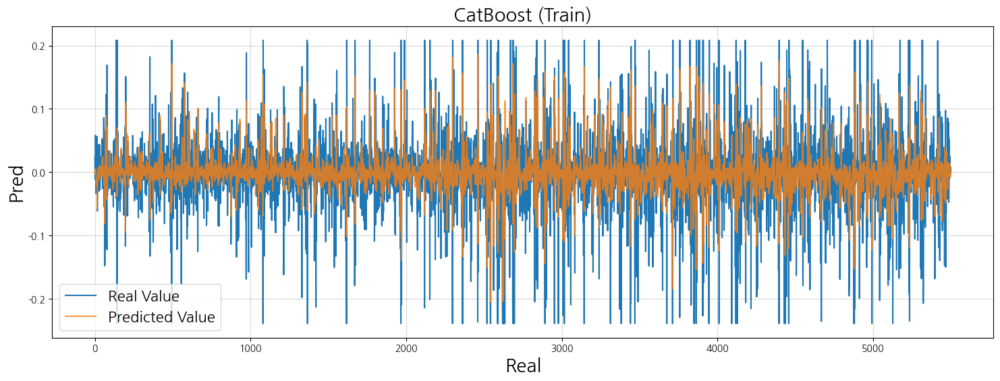

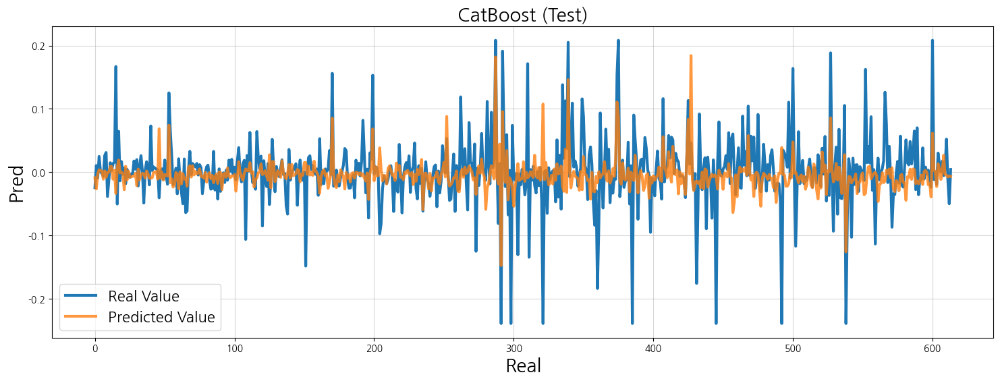

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,CatBoost,Train set,0.0420,0.0018,0.0291,0.0291,0.0195,0.0195,0.5111
1,CatBoost,Test set,0.0502,0.0025,0.0316,0.0316,0.0179,0.0179,0.1227
2,CatBoost,Entire population,0.0429,0.0018,0.0293,0.0293,0.0194,0.0194,0.4796


Saved: ./Result/Screening_Report_CatBoostRegressor.csv

   [CatBoostRegressor] Feature Screening Report (Normalized to 100%)
>>> [Cumulative Importance >= 99.0%] (Delete Count: 639)
삭제변수명: ['cat__NICS산업분류_N40401.부동산', 'cat__KSIC소분류_11차_N74100.사업시설_유지ㆍ관리_서비스업', 'num__총수익_연결', 'num__평균근속월수', 'cat__Scope3자료출처_Extrapolated_from_prior_year', 'cat__NICS산업분류_N25302.다각화된_소비자_서비스', 'num__환경등급__diff1', 'num__fe_배출권_부족비율__diff1', 'cat__KSIC소분류_11차_C27300.사진장비_및_광학_기기_제조업', 'cat__KSIC세분류_11차_C26220.인쇄회로기판_및_전자부품_실장기판_제조업', 'cat__Trucost산업_Electric_Utilities', 'missing__missingindicator_연간급여총액', 'missing__missingindicator_매출원가_연결', 'cat__KSIC중분류_11차_N76000.임대업', 'cat__KSIC소분류_11차_J59100.영화__비디오물__방송_프로그램_제작_및_배급업', 'cat__Trucost산업_Independent_Power_and_Renewable_Electricity_Producers', 'cat__KSIC소분류_11차_H51100.항공_여객_운송업', 'cat__KSIC중분류_11차_L68000.부동산업', 'missing__missingindicator_ESG등급', 'cat__KSIC세분류_11차_N74100.사업시설_유지ㆍ관리_서비스업', 'cat__NICS산업분류_N30302.개인용품', 'cat__KSIC소분류_11차_C26100.반도체_제조업', 'cat_

,Feature,Feature Importance (Gini/Gain/Mask),Importance (%),Cumulative Importance (%)
0,num__fe_영업이익_매출,12.0281,12.0281,12.0281
1,num__EBITDA대매출액,9.5166,9.5166,21.5447
2,num__EBITDA대매출액__diff1,4.3779,4.3779,25.9226
3,num__fe_판관비율__diff1,2.6297,2.6297,28.5522
4,num__총자본회전율,2.5710,2.5710,31.1232
...,...,...,...,...
833,cat__KSIC대분류_11차_I00000.숙박_및_음식점업(55~56),0.0000,0.0000,100.0000
834,num__소계_평균가격_원_tCO2eq,0.0000,0.0000,100.0000
835,cat__KSIC대분류_11차_M00000.전문__과학_및_기술_서비스업(70~73),0.0000,0.0000,100.0000
836,cat__KSIC대분류_11차_P00000.교육_서비스업(85),0.0000,0.0000,100.0000


In [7]:
# Model Loaded
if METRIC_FINAL in ['RMSE']:
    best_scoreidx = np.argmin(scores[scores.Dataset=='Test set'][METRIC_FINAL])
else:
    best_scoreidx = np.argmax(scores[scores.Dataset=='Test set'][METRIC_FINAL])
BEST_ALGO = scores[scores.Dataset=='Test set'].iloc[best_scoreidx]['Algorithm']
BEST_MODEL, BEST_PARAMS = Loading_ModelBestParams(algo_name=BEST_ALGO)
OPTIMAL_THRESHOLD = BEST_PARAMS.get('optimal_threshold', 0.5)
if BEST_ALGO in ['MLP', 'CNN', 'TabNet']:
    KERAS = True
else:
    KERAS = False
    BEST_MODEL = modeling_featurename(BEST_MODEL, BEST_ALGO, X_colname)    

# Performance Evaluation
if METRIC_FINAL in ['RMSE']:
    Scores_Test = prediction_reg(BEST_MODEL, X_train, Y_train, X_test, Y_test,
                                 ALGO_NAME=BEST_ALGO, keras=KERAS)
else:
    Scores_Test = prediction_class(BEST_MODEL, X_train, Y_train, X_test, Y_test,
                                   threshold=OPTIMAL_THRESHOLD,
                                   LABEL_LIST=LABEL_LIST, ALGO_NAME=BEST_ALGO, keras=KERAS)
display(Scores_Test)

# Feature Importance
df_importance = modeling_featureimportance(BEST_MODEL, [0.5, 0.75, 0.9, 0.95, 0.99])
display(df_importance)

# XAI

## Explanation

[Auto-Config] Detected Algorithm: LightGBM | Type: Tree | Link: identity
[SHAP] Pipeline 객체가 감지되어 내부 스케일러로 데이터를 자동 변환합니다.
Total SHAP Calculation...: 2026-09-24 00:16:11.563612


 95%|=================== | 5203/5500 [00:15<00:00]       

SHAP values saved to /workspace/DataScience/DIVE/Project/CO2XAI/Model/shap_values_LightGBM_20260924_001628.pkl

[Train Dataset Contribution Calculation]: 2026-09-24 00:16:28.472856
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 3600.24it/s]


,Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)",Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)"
0,num__fe_signed_log1p_연간급여총액,0.0009,1.8393,0.0038,0.0124,0.0270,0.5999,0.5942,NaN,num__fe_영업이익_매출,0.0056,11.2894,0.0113,-0.2633,-0.5390,-0.8607,-0.9207,NaN
1,num__부채총계_연결,0.0009,1.7772,0.0020,0.0313,0.0526,0.3188,0.6303,NaN,num__EBITDA대매출액,0.0041,8.2378,0.0082,-0.2385,-0.4885,-0.8039,-0.9335,NaN
2,num__경쟁_평균가격_원_tCO2eq,0.0009,1.7718,0.0018,0.0030,0.0037,0.6792,0.7345,NaN,num__경매_거래량_천톤,0.0013,2.5888,0.0025,-0.0416,-0.0826,-0.6888,-0.7504,NaN
3,num__총자본회전율,0.0008,1.6208,0.0013,0.0238,0.0640,0.3498,0.0539,NaN,num__fe_Scope3_매출집약도__diff1,0.0012,2.3959,0.0024,-0.0028,0.0139,-0.1723,-0.1907,NaN
4,num__fe_판관비율,0.0008,1.5816,0.0017,-0.0121,-0.0308,0.6038,0.8085,NaN,num__노동생산성,0.0011,2.1050,0.0025,-0.0549,-0.1219,-0.2356,-0.6284,NaN



[Test Dataset Contribution Calculation]: 2026-09-24 00:16:28.840046
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 7247.80it/s]


,Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)",Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)"
0,num__경매_거래량_천톤,0.0027,6.1199,0.0027,-0.0160,0.0023,0.0885,0.0974,NaN,num__fe_영업이익_매출,0.0054,12.0262,0.0106,-0.2073,-0.7238,-0.8718,-0.9238,NaN
1,num__부채총계_연결,0.0009,1.9085,0.0035,0.0101,-0.0073,0.0934,-0.1762,NaN,num__EBITDA대매출액,0.0042,9.3251,0.0082,-0.2128,-0.6716,-0.8577,-0.9443,NaN
2,num__fe_판관비율,0.0007,1.5854,0.0016,0.0044,-0.0025,0.5569,0.7906,NaN,num__fe_Scope3_매출집약도__diff1,0.0014,3.2128,0.0031,-0.0443,-0.0074,-0.3703,-0.6870,NaN
3,num__fe_영업현금흐름_자산,0.0007,1.4598,0.0013,-0.0769,-0.3537,0.7281,0.9102,NaN,num__노동생산성,0.0010,2.2983,0.0032,-0.0971,-0.1203,-0.2221,-0.6998,NaN
4,num__fe_판관비율__diff1,0.0006,1.3567,0.0012,-0.1155,0.2213,0.5298,0.6795,NaN,num__EBITDA대매출액__lag1,0.0010,2.1795,0.0021,-0.1315,-0.4074,-0.6221,-0.7341,NaN



[Train Dataset Beeswarm Visualization]: 2026-09-24 00:16:29.012298
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


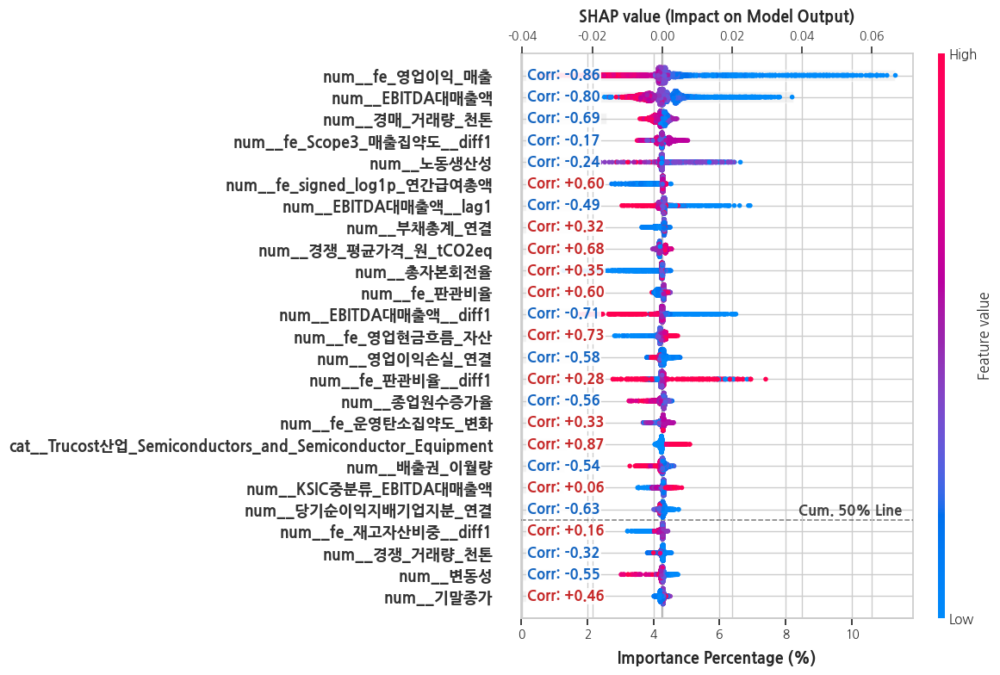


[Test Dataset Beeswarm Visualization]: 2026-09-24 00:16:29.539410
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


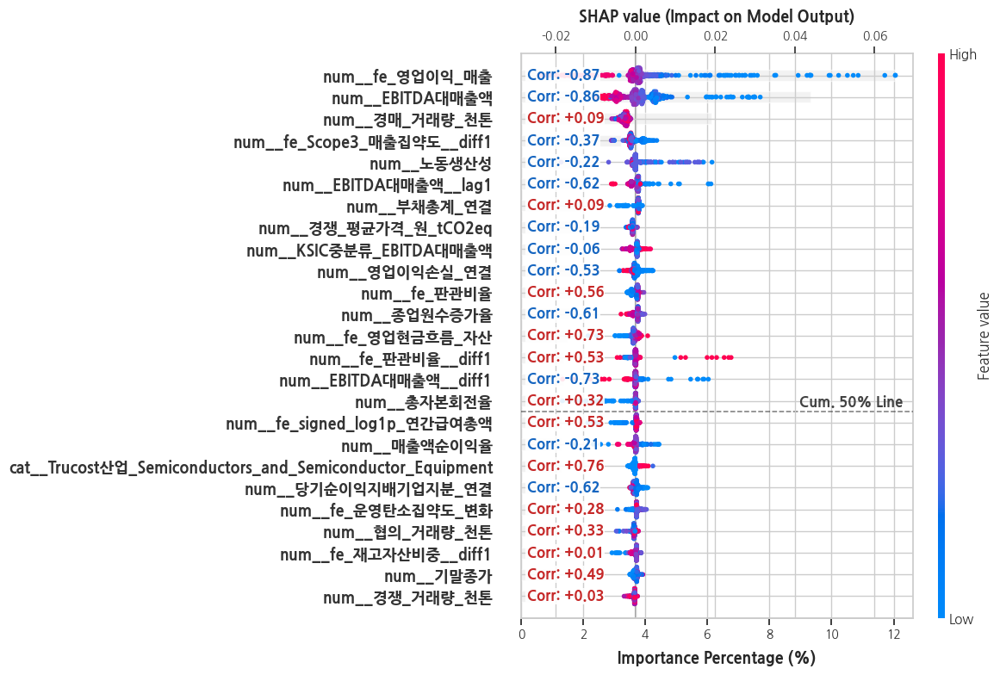


[Test Dataset Sensitivity Analysis]: 2026-09-24 00:16:29.780126
Sensitivity Analysis (ICE & PDP Plot) for Top 25 Features...


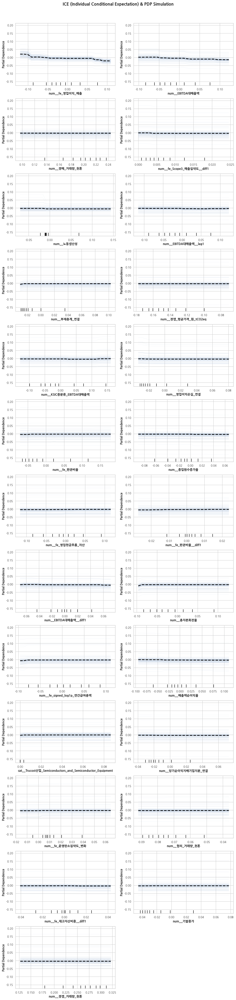


[Train Dataset Individual]: 2026-09-24 00:16:35.549701
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 1049


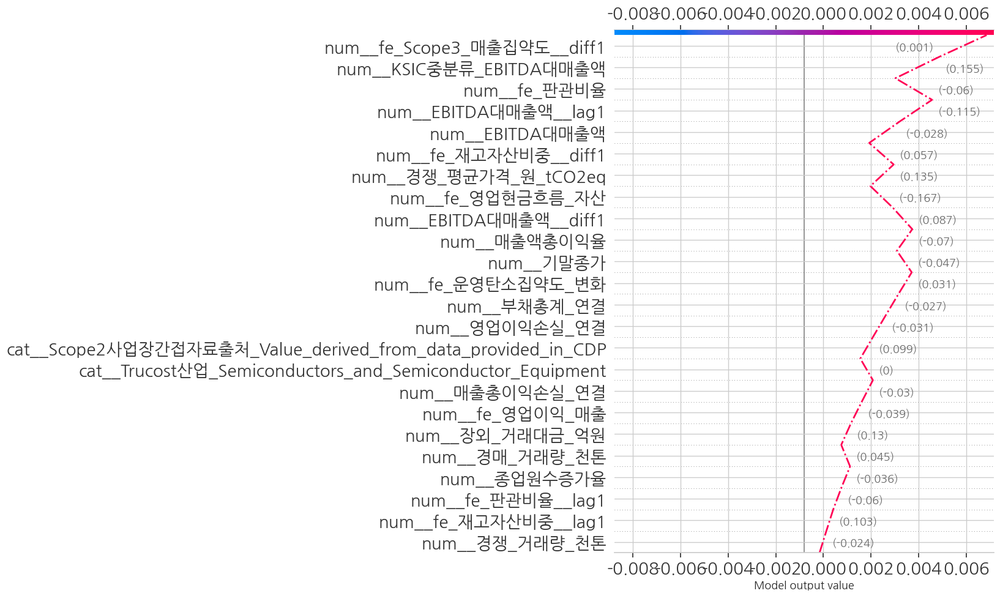


[Test Dataset Individual]: 2026-09-24 00:16:35.674179
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 355


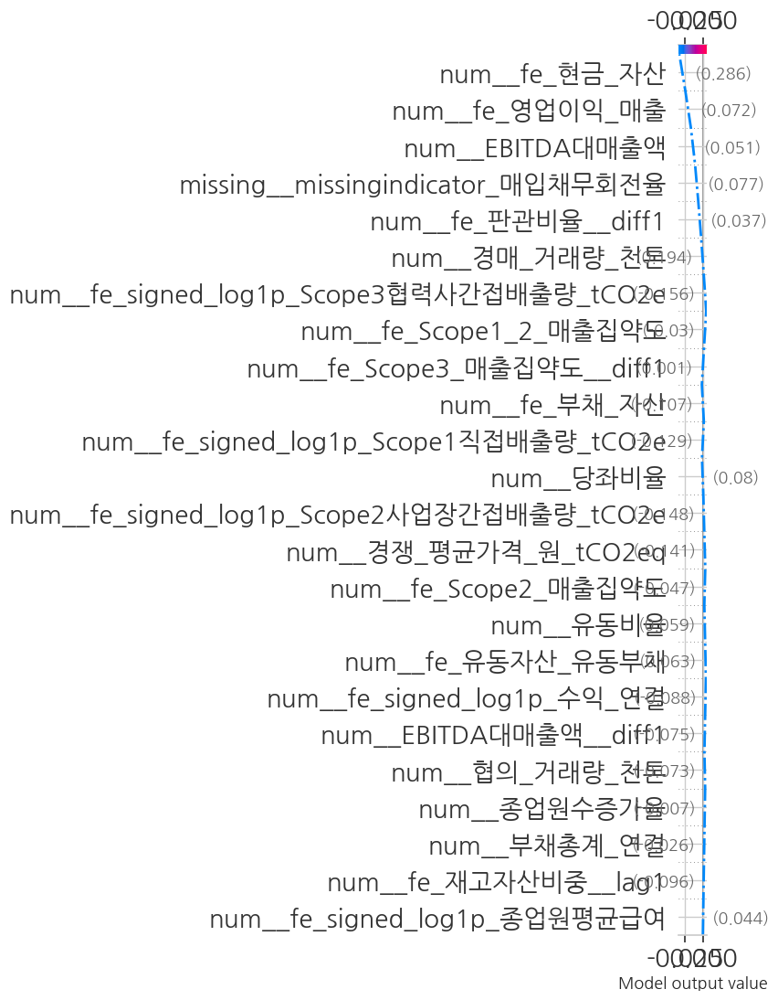

In [11]:
# Rename of Columns
X_selected = None
# df_domain_rename = pd.read_excel(os.path.join(FOLDER_GDM, '[Rename_20251228].xlsx'), sheet_name='Features_SI')
# df_domain_rename = {i[0]:i[1] for i in df_domain_rename[['변수설명(한글)', '변수설명(영어)']].values}
# if LANGUAGE == 'kr':
#     X_selected = [col for col in X_colname if col in list(df_domain_rename.keys())]
# else:
#     X_selected = [df_rename[col] for col in X_colname if col in list(df_domain_rename.keys())]

# SHAP 실행
explanation_SHAP(
    model=BEST_MODEL, 
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    X_colname=X_colname, X_selected=X_selected,
    interaction=INTERACTION,
    interaction_samples=INTERACTION_SAMPLES,
    interaction_batch=INTERACTION_BATCH,
    max_display=X_TOP_DISPLAY-25,
)


## Group Analysis


★★★ Subgroup Performance (Regression Fairness): [num__fe_Scope1_2_매출집약도] ★★★


,Subgroup Target,Group Name,N,RMSE,MAE,MedAE,MSPE,MAPE,MedAPE,R2
0,num__fe_Scope1_2_매출집약도,1,488,0.0524,0.0320,0.0191,0.0027,0.0320,0.0191,0.1202
1,num__fe_Scope1_2_매출집약도,2,126,0.0389,0.0265,0.0159,0.0015,0.0265,0.0159,0.2177



★★★ Subgroup Analysis Pipeline: 기준 변수 [num__fe_Scope1_2_매출집약도] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_LightGBM_20260924_001628.pkl
👉 [Success] Loaded SHAP value feature names have been updated in-memory!



################################################################################
🚀 실행 중인 데이터셋: [ Train Set ]
################################################################################

------------------------------------------------------------
### [Train Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 3725.41it/s]



------------------------------------------------------------
### [num__fe_Scope1_2_매출집약도] - 1 Group Analysis (Train Set) ###
------------------------------------------------------------
* 샘플 수 - Train: 4567명

[1] 1. Calculate Contributions (Train)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 3763.38it/s]



[1] 2. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


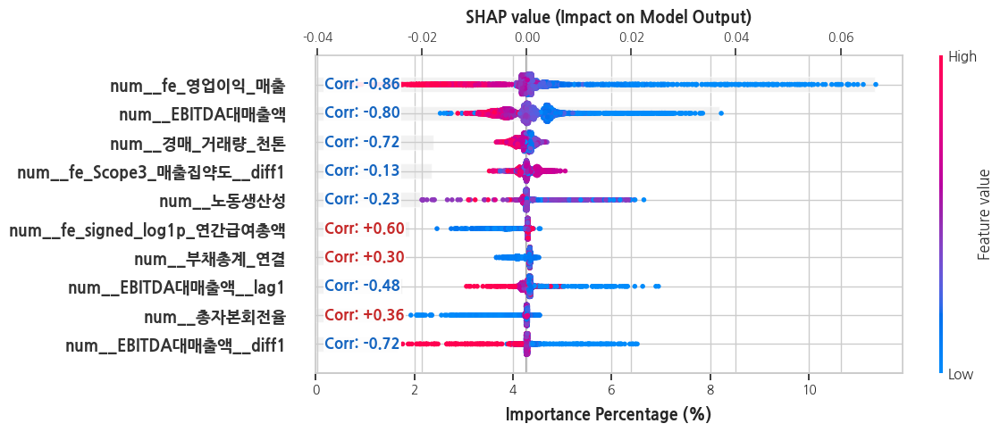

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 4010.85it/s]



------------------------------------------------------------
### [num__fe_Scope1_2_매출집약도] - 2 Group Analysis (Train Set) ###
------------------------------------------------------------
* 샘플 수 - Train: 933명

[2] 1. Calculate Contributions (Train)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 6802.24it/s]



[2] 2. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


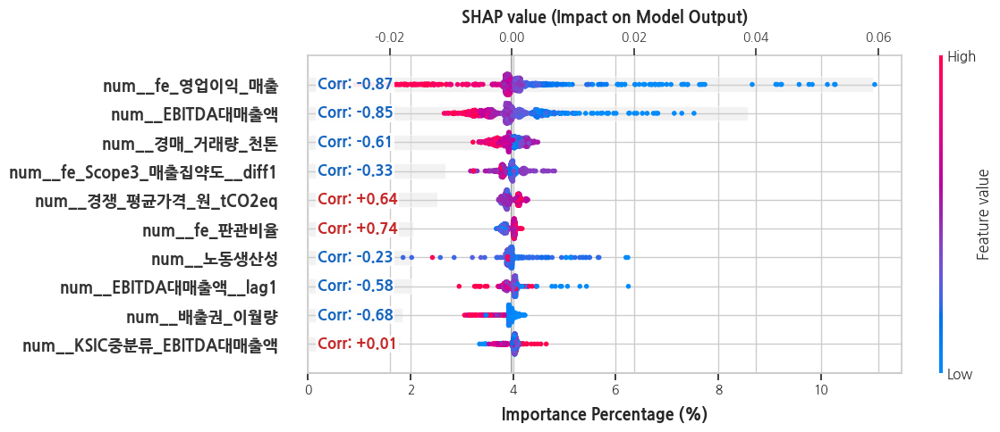

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 6848.39it/s]


### Group Rank & Direction Master Table (Train Set, Split by: num__fe_Scope1_2_매출집약도) ###


,Feature,Rank_Total,DirectionPearson_Total,Directional Crach,Rank Reversal,Intensity Disparity
3,num__fe_Scope3_매출집약도__diff1,4,-0.1747,NaN,NaN,1 vs 2 격차(0.211)
5,num__fe_signed_log1p_연간급여총액,6,0.5506,NaN,[9위차] 1(6) vs 2(15),NaN
7,num__부채총계_연결,8,0.1961,NaN,[5위차] 1(7) vs 2(12),NaN
8,num__경쟁_평균가격_원_tCO2eq,9,0.6893,NaN,[6위차] 2(5) vs 1(11),NaN
9,num__총자본회전율,10,0.3488,NaN,[9위차] 1(9) vs 2(18),1 vs 2 격차(0.103)
...,...,...,...,...,...,...
833,missing__missingindicator_매출대비온실가스직접외부비용비율_pct,265,NaN,NaN,[16위차] 2(249) vs 1(265),NaN
834,missing__missingindicator_온실가스직접외부비용_백만USD,265,NaN,NaN,[16위차] 2(249) vs 1(265),NaN
835,missing__missingindicator_총매출_백만USD,265,NaN,NaN,[16위차] 2(249) vs 1(265),NaN
836,missing__missingindicator_Scope3협력사간접배출량_tCO2e,265,NaN,NaN,[16위차] 2(249) vs 1(265),NaN



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Train Set)


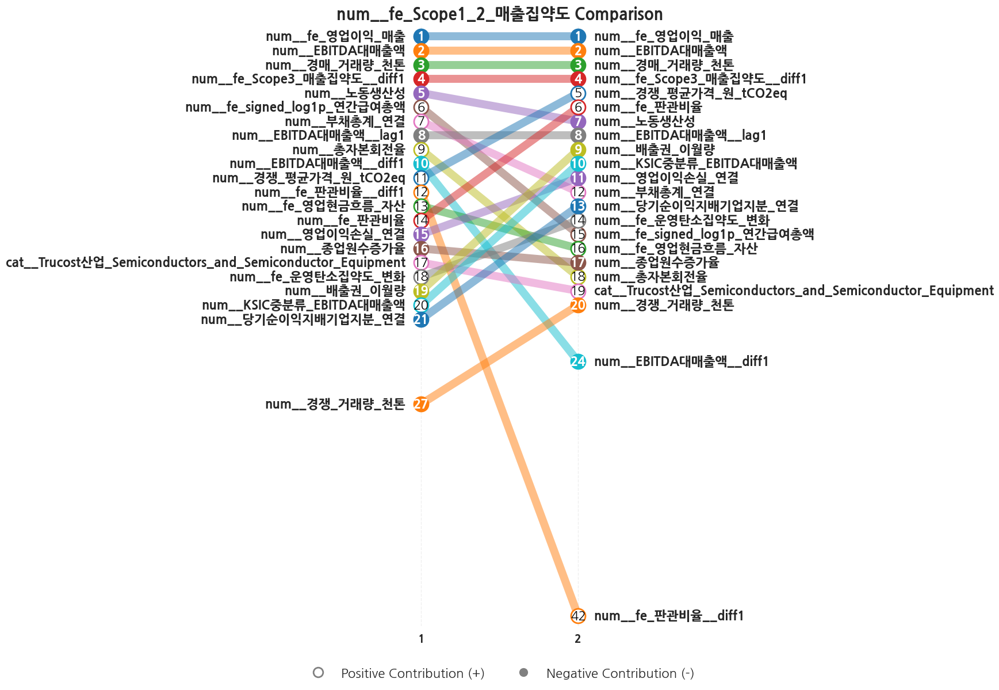


📊 Custom Ribbon Bump Chart: 하위 집단 간 Feature 중요도 흐름 (Train Set)


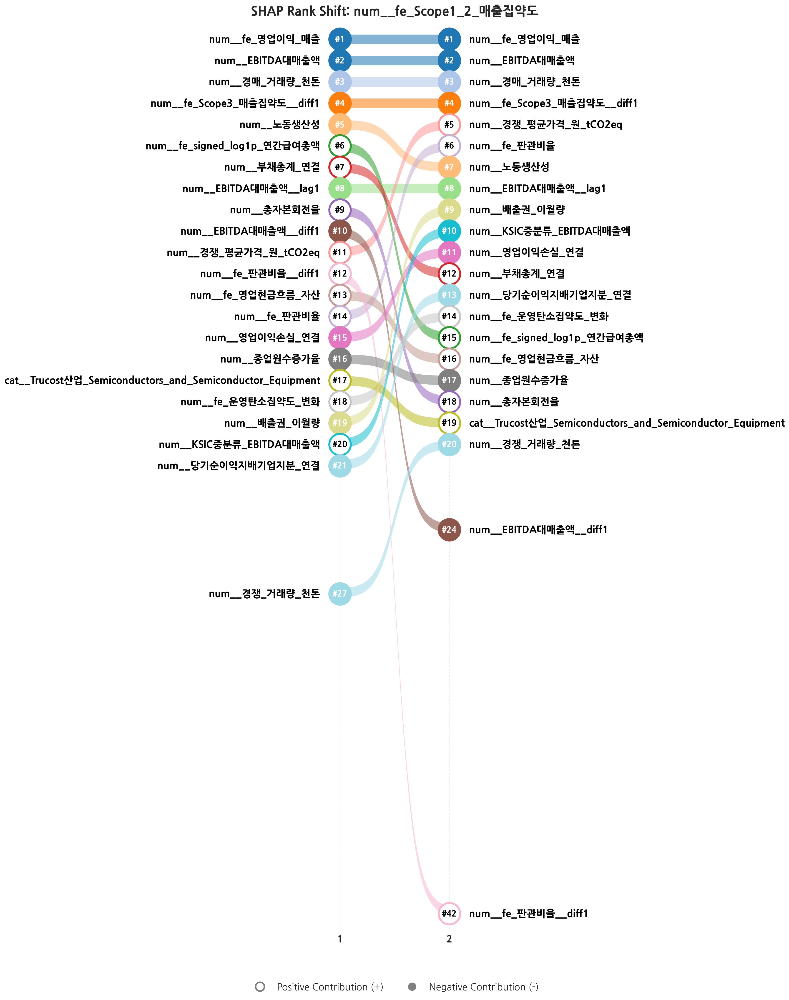


마스터 테이블이 저장되었습니다: /workspace/DataScience/DIVE/Project/CO2XAI/Result/FeatureImportance_LightGBM_Train_num__fe_Scope1_2_매출집약도.csv



################################################################################
🚀 실행 중인 데이터셋: [ Test Set ]
################################################################################

------------------------------------------------------------
### [Test Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 7257.47it/s]



------------------------------------------------------------
### [num__fe_Scope1_2_매출집약도] - 1 Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 488명

[1] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 7321.61it/s]



[1] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


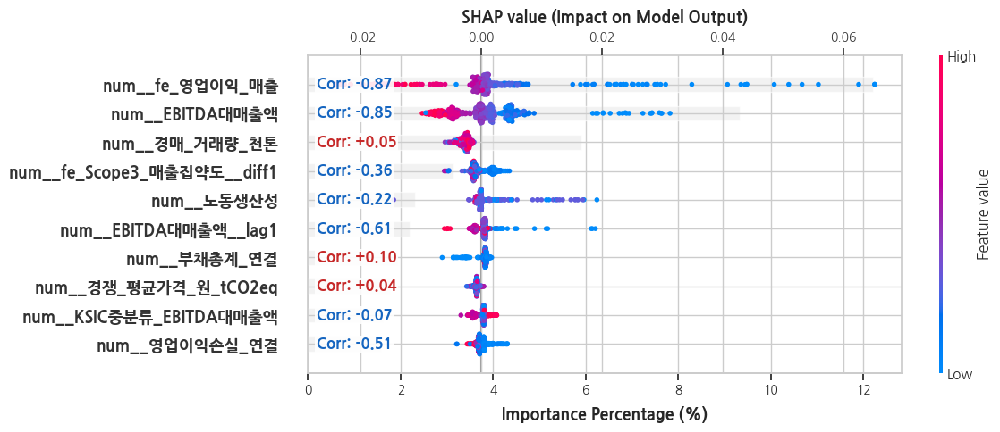

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 7531.56it/s]



------------------------------------------------------------
### [num__fe_Scope1_2_매출집약도] - 2 Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 126명

[2] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 9032.22it/s]



[2] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


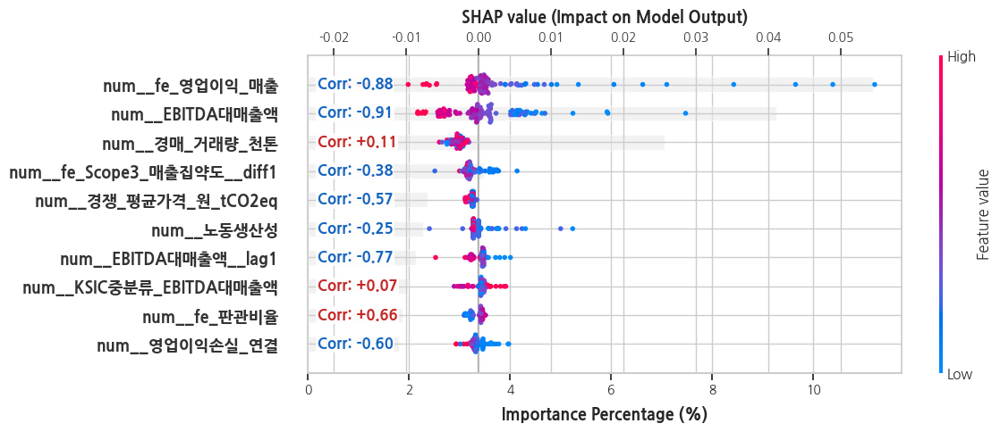

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 9198.52it/s]


### Group Rank & Direction Master Table (Test Set, Split by: num__fe_Scope1_2_매출집약도) ###


,Feature,Rank_Total,DirectionPearson_Total,Directional Crach,Rank Reversal,Intensity Disparity
5,num__EBITDA대매출액__lag1,6,-0.6112,NaN,NaN,1 vs 2 격차(0.182)
6,num__부채총계_연결,7,0.0495,NaN,[4위차] 1(7) vs 2(11),NaN
7,num__경쟁_평균가격_원_tCO2eq,8,-0.0000,NaN,[3위차] 2(5) vs 1(8),NaN
9,num__영업이익손실_연결,10,-0.4371,NaN,NaN,1 vs 2 격차(0.141)
10,num__fe_판관비율,11,0.5101,NaN,[6위차] 2(9) vs 1(15),NaN
...,...,...,...,...,...,...
833,missing__missingindicator_매출대비온실가스직접외부비용비율_pct,256,NaN,NaN,[21위차] 2(234) vs 1(255),NaN
834,missing__missingindicator_온실가스직접외부비용_백만USD,256,NaN,NaN,[21위차] 2(234) vs 1(255),NaN
835,missing__missingindicator_총매출_백만USD,256,NaN,NaN,[21위차] 2(234) vs 1(255),NaN
836,missing__missingindicator_Scope3협력사간접배출량_tCO2e,256,NaN,NaN,[21위차] 2(234) vs 1(255),NaN



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Test Set)


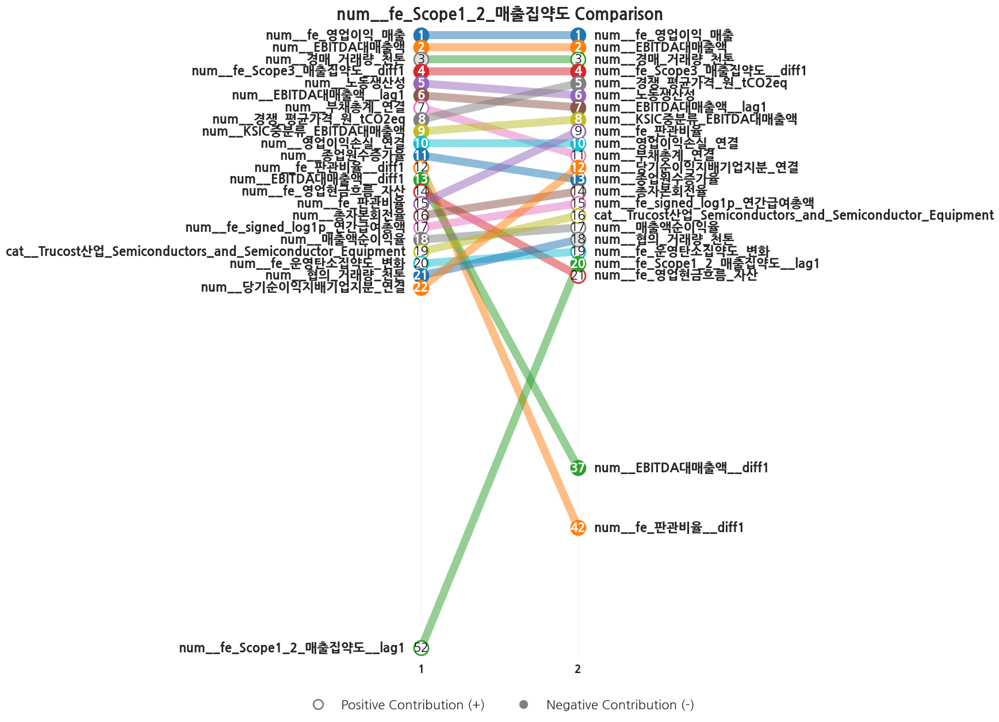


📊 Custom Ribbon Bump Chart: 하위 집단 간 Feature 중요도 흐름 (Test Set)


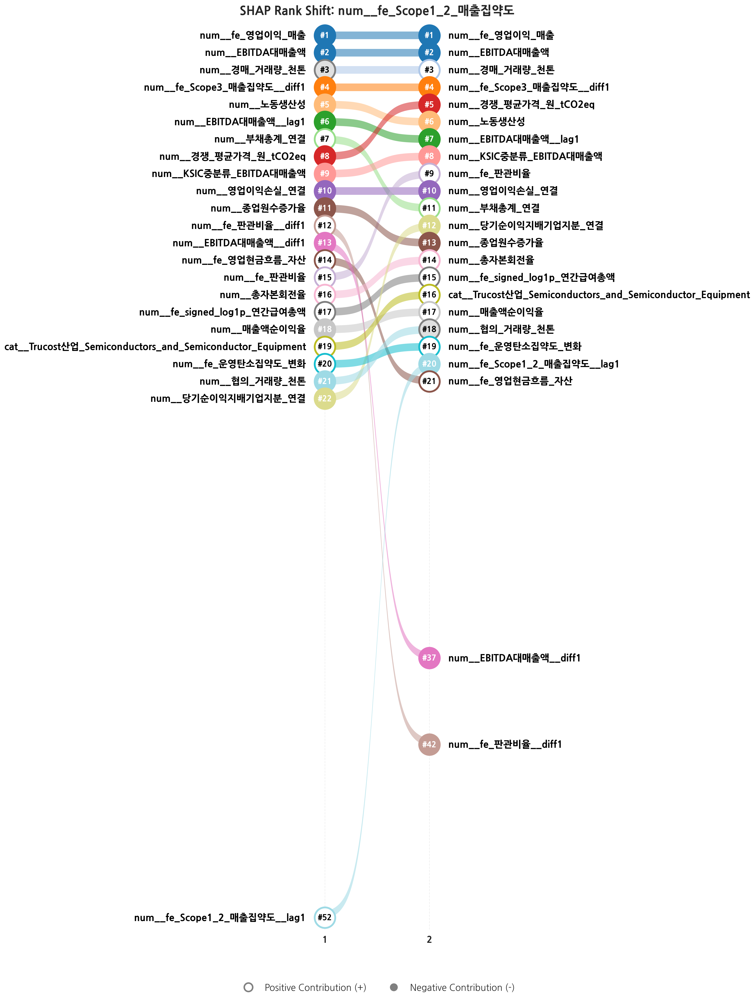


마스터 테이블이 저장되었습니다: /workspace/DataScience/DIVE/Project/CO2XAI/Result/FeatureImportance_LightGBM_Test_num__fe_Scope1_2_매출집약도.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [12]:
# 연가구소득
target_group = 'num__fe_Scope1_2_매출집약도'
# groups = {f"{target_group}_{val}": val for val in sorted(X_test[target_group].dropna().unique())}
groups = {
    '1': lambda x: x < 0,
    '2': lambda x: x>= 0
}
key_features=None

df_fairness = evaluation_reg_GroupFairness(
    best_model=BEST_MODEL,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
)

df_comparison = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_train=X_train, X_test=X_test,
    X_colname=X_colname,
    # scaler_dict=BEST_PARAMS['scaler_type'],
    best_algo=BEST_ALGO,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

# Causality Analysis

# Others

In [ ]:
### Date and Author: 20260916, Kyungwon Kim ###
def preprocessing_CarbonFinance(
    df_raw,
    year_min=None, year_max=None,
    industry_filter=None,
    Y_colname='target__EBITDA대매출액_t1',
    firm_id_col='meta__종목코드',
    feature_year_col='meta__feature_year',
    target_year_col='meta__target_year',
    drop_firm_dummies=True,
    drop_meta_cols=True,
    create_lags=True,
    lag_features=None,
    X_delete=None
):
    """
    탄소-ESG-재무 데이터셋의 패널 구조 정합, 동태적 시차 변수 생성 및 누수 방지 전처리 함수
    
    Returns:
        df_prep (pd.DataFrame): 전처리 완료된 데이터프레임
        YEAR_COLNAME (str): Time-split의 기준이 되는 컬럼명
    """
    start_time = time.time()
    df = df_raw.copy()
    print("\n" + "="*60)
    print(" [PHASE 1] Starting Domain-Specific Preprocessing (Carbon & ESG Finance)")
    print(f" Initial Shape: {df.shape}")
    print("="*60)

    # 1. 시계열 패널 정렬 (종목코드, 피처연도 기준 정렬 필수)
    if firm_id_col in df.columns and feature_year_col in df.columns:
        print(f"▶ Sorting Panel: By [{firm_id_col}] & [{feature_year_col}]")
        df = df.sort_values(by=[firm_id_col, feature_year_col]).reset_index(drop=True)

    # 2. 기간 필터링 (Target Year 기준)
    if target_year_col in df.columns:
        if year_min is not None:
            df = df[df[target_year_col] >= year_min]
        if year_max is not None:
            df = df[df[target_year_col] <= year_max]
        print(f"▶ Target Year Filter: {year_min} ~ {year_max} (Remaining Rows: {len(df):,})")

    # 3. 특정 산업군 필터링 (필요 시)
    if industry_filter is not None:
        target_ind_cols = [c for c in df.columns if any(ind in c for ind in industry_filter)]
        if target_ind_cols:
            ind_mask = df[target_ind_cols].sum(axis=1) > 0
            df = df[ind_mask].copy()
            print(f"▶ Industry Filter Applied: {industry_filter} (Remaining Rows: {len(df):,})")

    # 4. 가설 A, B 검증을 위한 동태적 패널 변수 생성 (Lag-1 및 1년 변화량 Diff-1)
    if create_lags and firm_id_col in df.columns:
        if lag_features is None:
            # 기본 권장 핵심 가설 변수군
            lag_features = [
                # [가설 A: 탄소/배출권 리스크]
                'num__fe_배출권_부족비율',
                'num__fe_배출권_잠재탄소비용_원',
                'num__매출대비온실가스직접외부비용비율_pct',
                'num__fe_Scope1_2_매출집약도',
                'num__fe_Scope3_매출집약도',
                # [가설 B: 사회공헌 완충 및 인적자본]
                'num__fe_signed_log1p_기부금_원',
                'num__사회등급',
                'num__환경등급',
                'num__노동생산성',
                # [운영/조절 변수]
                'num__EBITDA대매출액',
                'num__fe_시장지배력',
                'num__fe_재고자산비중',
                'num__fe_판관비율'
            ]
        
        valid_lag_cols = [c for c in lag_features if c in df.columns]
        print(f"\n▶ Generating Lag-1 ($t-1$) & Diff-1 ($\Delta$) for {len(valid_lag_cols)} Features...")
        for col in valid_lag_cols:
            df[f'{col}__lag1'] = df.groupby(firm_id_col)[col].shift(1)
            df[f'{col}__diff1'] = df[col] - df[f'{col}__lag1']
        print(f"   ▷ Shape after Lag Generation: {df.shape}")

    # 5. 개별 종목 더미 제거 (트리 모델 암기 및 과적합 방지)
    if drop_firm_dummies:
        firm_dummy_cols = [c for c in df.columns if c.startswith('cat__종목코드_')]
        if firm_dummy_cols:
            df = df.drop(columns=firm_dummy_cols)
            print(f"▶ Dropped Individual Firm Dummies: {len(firm_dummy_cols)} columns dropped")

    # 6. 불필요한 메타 컬럼 정리 (target_year_col은 modeling split을 위해 보존)
    if drop_meta_cols:
        meta_to_drop = [c for c in df.columns if c.startswith('meta__') and c != target_year_col]
        df = df.drop(columns=meta_to_drop)
        print(f"▶ Cleaned Unused Meta Columns: {meta_to_drop}")

    # 7. 사용자 정의 추가 삭제 변수 (X_delete)
    if X_delete is not None:
        user_drop = [c for c in X_delete if c in df.columns]
        df = df.drop(columns=user_drop)
        print(f"▶ Dropped User-specified Columns (X_delete): {len(user_drop)} columns")

    YEAR_COLNAME = target_year_col
    print(f"\nCompleted Domain Preprocessing in {time.time()-start_time:.2f}s")
    print(f"Final Data Shape: {df.shape} | Assigned YEAR_COLNAME: '{YEAR_COLNAME}'\n")

    return df, YEAR_COLNAME